In [60]:
import numpy as np
import matplotlib.pyplot as plt
import random
from myalgo import M_method_feas, M_method_opt
import pickle
from timeit import default_timer as timer
from qiskit_optimization.translators import from_docplex_mp
from docplex.mp.model_reader import ModelReader
import cvxpy as cp
from scipy.optimize import minimize
import scipy as sp
from matplotlib.colors import ListedColormap
import tqdm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import os
import warnings
from collections import Counter

import pennylane as qml
from pennylane import qaoa
from pytket.passes import AutoRebase, FullPeepholeOptimise, SequencePass, DecomposeBoxes
from qnexus.models.job_status import JobStatusEnum


from qaoa_sampling_oneshot import qaoa_sampling_oneshot, maqaoa_sampling_oneshot



## Funcs

### Settled functs

In [61]:
### general

def symmetrize(Q):
    return (Q + Q.T) / 2

def L1_norm(Q, const):
    return const + np.sum(np.abs(Q))

def L1_norm_hot(Q, const, n_bits, temperature, min_pfeas):
    return L1_norm(Q, const) + temperature * (n_bits * np.log(2) - np.log(1-min_pfeas))

def evaluate_energy(solution, Q, const):
    return const + np.dot(solution, np.dot(Q, solution))


# NPP specifics

def get_QUBO_NPP(N, P, M, seed, penalization=True, objective=True):
    """build a NPP QUBO with N integers, P partitions, M penalty factor, for problem identified with seed"""
    Q, const = np.zeros((N * P, N * P)), 0
    if objective:
        numbs = build_numbs_set(N, P, seed)
        Ho, const_o = build_obj_NPP(numbs, N, P)
        Q += Ho
        const += const_o
    if penalization:
        Hp, const_p = build_pen_NPP(N, P)
        Q += M * Hp
        const += M * const_p
    return Q, const

def build_numbs_set(N, P, seed):
    random.seed(seed)
    numbs = np.array([int(1000 * random.uniform(0.0, 1.0)) for _ in range(N)])
    total = sum(numbs)
    if numbs[-1] - (total % P) > 1:
        numbs[-1] -= total % P
    else:
        numbs[-1] += P - (total % P)
    total = sum(numbs)
    return numbs

def idx_onehot(i, p, P):
    return i * P + p

def build_obj_NPP(numbs, N, P):
    H = np.zeros((N * P, N * P))
    alpha = np.sum(numbs) / P
    for p in range(P):
        for i in range(N):
            H[idx_onehot(i, p, P), idx_onehot(i, p, P)] = numbs[i]**2 - 2*alpha*numbs[i]
            for i_prime in range(N):
                if i_prime == i:
                    continue
                H[idx_onehot(i, p, P), idx_onehot(i_prime, p, P)] = numbs[i] * numbs[i_prime]
    const = P * alpha**2
    H = symmetrize(H)
    return H, const

def build_pen_NPP(N, P):
    H = np.zeros((N * P, N * P))
    for p in range(P):
        for i in range(N):
            H[idx_onehot(i, p, P), idx_onehot(i, p, P)] = -1
            for p_prime in range(P):
                if p_prime == p:
                    continue
                H[idx_onehot(i, p, P), idx_onehot(i, p_prime, P)] = 1
    const = N
    H = symmetrize(H)
    return H, const


# TSP specific

def build_adjacency(Nc, info_instance, info_type):
    if info_type == "circle":
        # trivial construction of adj. matrix of graph with N cities on a circle. Modify this function to get more complex structures
        coordinates = [(1_000_000 * np.cos((index / Nc) * 2 * np.pi), 1_000_000 * np.sin((index / Nc) * 2 * np.pi)) for index in range(Nc)]
        distance_table = [[int(np.sqrt((coordinates[c_1][0] - coordinates[c_0][0]) ** 2 + (coordinates[c_1][1] - coordinates[c_0][1]) ** 2)) for c_0 in range(Nc)] for c_1 in range(Nc)]
    elif info_type == "seed":
        # random construction of the adjacency matrix, based on euclidian distance. (cities are uniformly randomly placed inside a square)
        seed = info_instance
        np.random.seed(seed)
        coordinates = 1e6 * np.array( [np.random.uniform(low = -1, high = 1, size = 2) for i in range(Nc)] )
        distance_table = [[int(np.sqrt((coordinates[c_1][0] - coordinates[c_0][0]) ** 2 + (coordinates[c_1][1] - coordinates[c_0][1]) ** 2)) for c_0 in range(Nc)] for c_1 in range(Nc)]
    elif info_type == "adjacency":
        distance_table = info_instance
    return np.array(distance_table)

def build_obj_TSP(distances, Nc):
    H = np.zeros((Nc**2, Nc**2))
    for t in range(Nc):
        for i in range(Nc):
            for i_prime in range(Nc):
                if i_prime != i:
                    H[idx_onehot(t, i, Nc), idx_onehot((t+1)%Nc, i_prime, Nc)] = distances[i, i_prime]
    H = symmetrize(H)
    const = 0
    return H, const

def build_pen_TSP(Nc):
    H = np.zeros((Nc**2, Nc**2))
    for t in range(Nc):
        for i in range(Nc):
            H[idx_onehot(t, i, Nc), idx_onehot(t, i, Nc)] = -2
            for i_prime in range(Nc):
                if i_prime != i:
                    H[idx_onehot(t, i, Nc), idx_onehot(t, i_prime, Nc)] += 1
            for t_prime in range(Nc):
                if t_prime != t:
                    H[idx_onehot(t, i, Nc), idx_onehot(t_prime, i, Nc)] += 1
    const = 2*Nc
    H = symmetrize(H)
    return H, const


def get_QUBO_TSP(Nc, M, info_instance, info_type, objective = True, penalization=True):
    # build a TSP QUBO with Nc cities, M penalty factor, for problem identified with seed or on a circle
    Q, const = np.zeros((Nc**2, Nc**2)), 0
    if objective:
        distances = build_adjacency(Nc, info_instance, info_type)
        Ho, const_o = build_obj_TSP(distances, Nc)
        Q += Ho
        const += const_o
    if penalization:
        Hp, const_p = build_pen_TSP(Nc)
        Q += M*Hp
        const += M*const_p
    return Q, const


# PO specific


def lower_bound_obj_PO(N, w, info_instance):
    n_bits = N*w
    directory, vseed = info_instance
    filename = f"../../data/{directory}/{n_bits}/random{vseed}_{n_bits}.lp"
    m = ModelReader.read(filename, ignore_names=True)
    qp = from_docplex_mp(m)
    n = qp.get_num_binary_vars()
    obj = qp.objective
    Q = obj.quadratic.to_array()
    L = obj.linear.to_array()

    Q_tilde = np.ndarray((n+1, n+1))
    Q_tilde[1:, 1:] = Q
    Q_tilde[0, 0] = 0
    Q_tilde[0, 1:] = .5*L.T
    Q_tilde[1:, 0] = .5*L
    X = cp.Variable((n+1, n+1), symmetric=True)
    constraints = [X >> 0]
    constraints += [X[i,i] == X[0,i] for i in range(1, n+1) ]
    constraints += [X[0,0] == 1]      ###### alternative way of imposing boundness, rather than  0 <= X_ij <= 1  for all i,j (2 previous lines)
    prob = cp.Problem(cp.Minimize(cp.trace(Q_tilde @ X)), constraints)
    prob.solve(solver = "MOSEK")
    return prob.value

def build_pen_PO(N, w):
    ''' return quadratic part and constant part of the penalization part of the hamiltonian '''
    # constraints in the formulation      Ax = b 
    A = np.array( [2**i for i in range(w-1, -1, -1)]*N )
    b = 2**w - 1
    # build [H, const] from [A, b]. easier formulation since b is scalar and A only 1 row, since there's only 1 constraint.
    H = np.outer(A, A)
    H -= 2*b*np.diag(A)
    const = b**2
    H = symmetrize(H)
    return H, const

def get_PO_obj(n_bits, info_instance):
    directory, vseed = info_instance
    filename = f"../../data/{directory}/{n_bits}/random{vseed}_{n_bits}.lp"
    m = ModelReader.read(filename, ignore_names=True)
    qp = from_docplex_mp(m)
    obj = qp.objective
    Q = obj.quadratic.to_array()
    L = obj.linear.to_array()
    Q = symmetrize(Q)
    return Q, L

def get_QUBO_PO(N, w, M, info_type, info_instance, objective = True, penalization=True):
    ''' build a PO QUBO with N stocks, w qubits per stock, M penalty factor, for problem identified with seed '''
    Q, const = np.zeros(((N*w), (N*w))), 0
    if objective:
        if info_type == "seed":
            Q_o, L_o = get_PO_obj(N*w, info_instance)
            Q += Q_o + np.diag(L_o)
        else:
            raise ValueError(f"info_type = {info_type} not understood for PO instance")
    if penalization:
        Hp, const_p = build_pen_PO(N, w)
        Q += M*Hp
        const += M*const_p
    return Q, const

In [62]:
def fit_temp_from_histograms(
    sd_eners, eners_qaoa, bins=50,
    use_probs=False, probs_qaoa=None, Q=None, const=None,
    n_retries=6, verbose=False
):
    """
    Fit an effective Gibbs temperature T* such that:
        p_model(E) ∝ g(E) * exp(-(E - E_min) / T*)
    matches the target distribution (exact QAOA probs or empirical samples).

    Returns
    -------
    temp_opt   : float, best-fit temperature
    bin_edges  : array
    model_hist : normalised model probabilities per bin
    qaoa_hist  : normalised target probabilities per bin
    result     : OptimizeResult (for diagnostics)
    """
    # ── 1. shared bin edges ──────────────────────────────────────────────
    all_eners = np.concatenate([sd_eners, eners_qaoa])
    bin_edges = np.histogram_bin_edges(all_eners, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emin = bin_edges[0]                     # use the global min, not sample min

    # ── 2. spectral density (prior) ──────────────────────────────────────
    sd_counts, _ = np.histogram(sd_eners, bins=bin_edges)
    sd_counts = sd_counts.astype(float)

    # ── 3. target distribution ───────────────────────────────────────────
    if use_probs:
        assert probs_qaoa is not None and Q is not None and const is not None
        n_qubits, _ = np.shape(Q)           # local variable, no shadowing
        state_energies = np.array([
            evaluate_energy(state_inttobin(i, n_qubits), Q, const)
            for i in range(2**n_qubits)
        ])
        bin_idx = np.clip(np.digitize(state_energies, bin_edges) - 1,
                          0, len(bin_centers) - 1)
        qaoa_prob = np.zeros(len(bin_centers))
        np.add.at(qaoa_prob, bin_idx, probs_qaoa)   # vectorised accumulation
    else:
        counts, _ = np.histogram(eners_qaoa, bins=bin_edges)
        qaoa_prob = counts / counts.sum()

    # guard against all-zero target
    if qaoa_prob.sum() == 0:
        raise ValueError("Target distribution is all-zero — check inputs.")

    # ── 4. model & loss ──────────────────────────────────────────────────
    def model_prob(log_temp):
        temp = np.exp(log_temp)
        # subtract max for numerical stability before exp
        log_w = -(bin_centers - emin) / temp
        log_w -= log_w.max()
        weights = np.exp(log_w) * sd_counts
        Z = weights.sum()
        return weights / Z if Z > 0 else np.zeros_like(weights)

    def loss_kl(log_temp):
        p = model_prob(log_temp[0])
        # KL(qaoa ‖ model)  — only where both are positive
        # clamp p to avoid log(qaoa/p) overflow when p is subnormal but nonzero
        p = np.clip(p, 1e-300, None)
        mask = qaoa_prob > 0
        if not mask.any():
            return 1e12                     # no overlap → huge penalty
        return float(np.sum(qaoa_prob[mask] * np.log(qaoa_prob[mask] / p[mask])))

    # ── 5. smart initial guesses ─────────────────────────────────────────
    # Primary: match variance of Gibbs on flat DOS to variance of target
    #   Var[E]_Gibbs ≈ T^2  →  T_init ≈ std(E_target)
    if use_probs:
        mean_e = np.dot(qaoa_prob, bin_centers)
        var_e  = np.dot(qaoa_prob, (bin_centers - mean_e)**2)
    else:
        var_e = np.var(eners_qaoa)
    t_var = max(np.sqrt(var_e), 1e-3)

    # Spread initial conditions over several decades around that estimate
    log_t_center = np.log(t_var)
    offsets = [0.0, 1.5, -1.5, 3.0, -3.0, 5.0]   # log-scale offsets
    x0_candidates = [log_t_center + d for d in offsets[:n_retries]]

    # ── 6. multi-start optimisation ──────────────────────────────────────
    best_result = None
    best_loss   = np.inf

    for x0 in x0_candidates:
        try:
            res = minimize(
                loss_kl, x0=[x0],
                method="Nelder-Mead",       # gradient-free; robust for 1-D
                options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 5000},
            )
            # accept only if converged and finite
            if res.fun < best_loss and np.isfinite(res.fun):
                best_loss   = res.fun
                best_result = res
                if verbose:
                    print(f"  x0={x0:.2f} → T={np.exp(res.x[0]):.4g}, KL={res.fun:.4g}")
        except Exception as e:
            if verbose:
                print(f"  x0={x0:.2f} failed: {e}")

    if best_result is None or not best_result.success:
        import warnings
        warnings.warn(
            f"Temperature fit may not have converged (best KL={best_loss:.4g}). "
            "Consider widening n_retries or checking your energy scale."
        )

    temp_opt  = np.exp(best_result.x[0])
    model_out = model_prob(best_result.x[0])
    return temp_opt, bin_edges, model_out, qaoa_prob, best_result

### New funcs

In [63]:

from pennylane import numpy as pl_np  # PennyLane's numpy wrapper (supports requires_grad)


def temperature_from_layers(p, N):
    return (2.8*p/(N**(3/2)))**-1

def layers_from_temperature(T, N):
    return N**(3/2) / (2.8*T)

def combine_obj_pen(popul, qaoa_samples, M):
    assert np.sum(popul[:,2]) == qaoa_samples

    ener_ls = []
    len_states, _ = np.shape(popul)
    for i in range(len_states):
        e = popul[i, 0] + M*popul[i, 1]
        ener_ls += int(popul[i,2])*[e]
    assert len(ener_ls) == qaoa_samples
    return ener_ls

def spectral_density(Q, const):
    n, _ = np.shape(Q)
    ener = np.array([ evaluate_energy(state_inttobin(i, n), Q, const) for i in range(2**n)])
    return ener

def state_inttobin(i, n):
    state_string = bin(i)[2:].zfill(n)
    return [int(b) for b in state_string]




# ──────────────────────────────────────────────
#   Main function
# ──────────────────────────────────────────────
def run_qaoa_with_solution(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    init_params=None,            # NEW: warm-start, shape (2, p); None → linear ramp + noise
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    mixer_weights=None,             # NEW: array of length num_qubits; None → standard X-mixer
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt:float = 1e-4,
) -> dict:
    """
    Run QAOA on a QUBO problem and return samples from the optimised circuit.

    The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
    Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

    Args:
        qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
                     Diagonal entries (i==i) are linear coefficients.
                     Off-diagonal entries can be upper-triangular or full;
                     symmetric duplicates are handled correctly.
        num_qubits : number of binary variables (= problem size n)
        p          : QAOA depth — number of (cost + mixer) layer pairs
        steps      : Adam optimisation steps
        stepsize   : Adam learning rate
        n_samples  : shots for final sampling from the optimised circuit
        seed       : RNG seed for reproducibility (None = random)
        verbose    : print cost every 10 steps

    Returns a dict with keys:
        "best_bitstring" : str   — bitstring of highest-probability basis state
        "best_x"         : list  — binary vector corresponding to best_bitstring
        "params"         : array — optimised [gammas, betas] of shape (2, p)
        "counts"         : dict  — {bitstring: count} from n_samples shots
        "cost_history"   : list  — cost value recorded every 10 steps
    """

    # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
    # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
    #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
    #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j: # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else: # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))
    cost_h  = qml.simplify( qml.dot(coeffs, obs) )

    # ── 1b. Build mixer Hamiltonian ────────────────────────────────
    if mixer_weights is None:
        mixer_h = qaoa.x_mixer(range(num_qubits))
    else:
        w = np.asarray(mixer_weights, dtype=float)
        if w.shape != (num_qubits,):
            raise ValueError(
                f"mixer_weights must have length num_qubits={num_qubits}, "
                f"got shape {w.shape}"
            )
        if np.any(w <= 0):
            raise ValueError("mixer_weights must be strictly positive")
        # Normalise so mean(w) = 1 → overall mixing scale comparable to standard X-mixer
        w_norm = w / np.mean(w)
        mixer_h = qml.simplify(
            qml.dot(w_norm.tolist(), [qml.PauliX(i) for i in range(num_qubits)])
        )
        if verbose:
            print(f"  Weighted mixer: raw w = {w.tolist()}")
            print(f"                  normalised w = {np.round(w_norm, 4).tolist()}")


    # ── 2. Devices ────────────────────────────────────────────────────────────
    dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

    # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
    def qaoa_ansatz(gammas, betas):
        # Equal superposition starting state  |+⟩^n
        for wire in range(num_qubits):
            qml.Hadamard(wires=wire)
        # Alternating cost / mixer layers
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)
            qaoa.mixer_layer(betas[layer], mixer_h)

    # ── 4. QNodes ─────────────────────────────────────────────────────────────
    @qml.qnode(dev_sv)
    def cost_node(params):
        """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
        qaoa_ansatz(params[0], params[1])
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(params):
        """Returns the full 2^n probability vector (exact, no shots)."""
        qaoa_ansatz(params[0], params[1])
        return qml.probs(wires=range(num_qubits))
    
    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(params):
        """Draws shots from the optimised circuit and returns counts."""
        qaoa_ansatz(params[0], params[1])
        return qml.counts(wires=range(num_qubits))

    # ── 5. Parameter initialisation: input-give orlinear ramp heuristic ──────────────────
    if init_params is not None:
        init_params = np.asarray(init_params, dtype=float)
        if init_params.shape != (2, p):
            raise ValueError(
                f"init_params shape {init_params.shape} doesn't match (2, p) = (2, {p})"
            )
        params = pl_np.array(init_params.copy(), requires_grad=True)
    else: # Empirically good starting point: γ small→large, β large→small
        rng    = np.random.default_rng(seed)
        noise  = rng.uniform(-0.05, 0.05, size=(2, p))   # tiny noise to break symmetry
        init_gammas = np.linspace(0.01, 1, p) + noise[0]
        init_betas  = np.linspace(1, 0.01, p) + noise[1]
        params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

    # ── 6. Optimisation ───────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_params = None
    best_cost = np.inf 

    epsilon = tolerance_opt
    step_check = 10
    for step in range(steps):
        params, cost_val = optimizer.step_and_cost(cost_node, params)
        if cost_val < best_cost:
            best_cost = cost_val
            best_params = params.copy()

        # cost_history.append(float(cost_val))
        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
            if len(cost_history)>1:
                diff_10 = np.abs(cost_history[-2] - cost_history[-1])
                if diff_10 < epsilon:
                    print(f"...breaking at iteration {step} out of {steps}")
                    break


    # ── 7. Draw samples (& extract best state)─────────────────────────────────
    probs = np.array(prob_node(best_params))

    # best_idx       = int(np.argmax(probs))
    # best_bitstring = format(best_idx, f"0{num_qubits}b")
    # best_x         = [int(b) for b in best_bitstring]
    # if verbose:
    #     print(f"\n  Best bitstring : {best_bitstring}")
    #     print(f"  Best x vector  : {best_x}")
    #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

    params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
    if draw_samples:
        counts = sample_node(params)
        return params, counts, probs, float(best_cost)
    else:
        return params, probs, float(best_cost)
    





def build_qaoa_ansatz_from_pars(Q, n, p, params):
    """
    Build ONLY the QAOA circuit function from already-trained parameters, no device,
    no simulation, no probability vector. Returns `full_circuit`, a zero-arg callable
    that applies the gates (+state preparation + p layers of cost + X mixer), meant to
    be dropped inside your own QNode / drawer / transpiler.
    """
    Q = np.asarray(Q, float)
    n = int(n)
    params = np.asarray(params, float).ravel()
    gammas, betas = params[:p], params[p:]

    qubo_dict = {idx: val for idx, val in np.ndenumerate(Q) if not np.isclose(val, 0)}
    # QUBO -> Ising (x_i = (1 - z_i)/2)
    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j: # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else: # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))
    cost_h  = qml.simplify( qml.dot(coeffs, obs) )
    mixer_h = qaoa.x_mixer(range(n))

    def state_prep():
        for wire in range(n):
            qml.Hadamard(wires=wire)

    def qaoa_layers(gammas=gammas, betas=betas):
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)                
            qaoa.mixer_layer(betas[layer], mixer_h)

    def full_circuit():
        state_prep()
        qaoa_layers(gammas, betas)

    return full_circuit









def select_normalization(Q_pen, const_pen, Q_obj, const_obj): # TODO: refine this
    max_all = np.max(np.abs(Q_pen + Q_obj + const_obj + const_pen))
    frob =  np.linalg.norm(Q_pen + Q_obj + const_obj + const_pen, ord = 'fro')
    spectral = np.linalg.norm(Q_pen + Q_obj + const_obj + const_pen, ord = 2)
    # print(f"Norms: max = {max_all}\t frob = {frob}\t spectral = {spectral}")
    return spectral

In [64]:
### normalized temperature and pipeline

def qaoa_sampling(problem_type, N_idx, info_instance, Mstrategy, eta_required, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
    temperature_normalized = temperature_from_layers(layers, n_bits)
    norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
    temperature_unnormalized = norm_guess * temperature_normalized

    beta = 1 / temperature_unnormalized
    min_pfeas = eta_required  # eta
    peak_max = 4 # 4 for NPP and TSP, 9 for PO
    if problem_type == "PO":
        E_LB = lower_bound_obj_PO(N, w, info_instance)
        peak_max = 25
    else:
        E_LB = 0
    if Mstrategy == "optimality":
        E_f = select_Ef(problem_type, N_idx)
        M_star, eta_guaranteed = M_method_opt(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_f, E_LB, log_stable = True)
    elif Mstrategy == "feasibility":
        M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temperature_unnormalized, min_pfeas)
    # print(f"With an instance with {n_bits} bits, {layers} layers and (thus) est. temp. (UNnorm) {np.round(temperature_unnormalized, 3)} [norm -> {np.round(temperature_normalized, 3)}], the appropriate M is {M_star}")
    # print(f"With an instance with {n_bits} bits, {layers} layers, M* is {M_star}, M_L1 is {M_L1}")
    # print(f"M choice from old strategy is {M_star}, norm guess is {norm_guess}; M_L1 is {M_L1}")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M_star, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M_star, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M_star, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")

    # Normalizing Q according to the temperature scaling we did in step 2
    Q_norm, const_norm = Q/norm_guess, const/norm_guess

    ## Re-normalizing Q
    norm_final = np.max(np.abs(Q_norm))
    Q_norm, const_norm = Q_norm/norm_final, const_norm/norm_final

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, draw_samples=True)

    ### 4. From [LCBO, X] computed sampled energies [E_o, E_p](both objective and penalization)
    eners = np.ndarray((len(states), 3))  # second index discriminate obj=0 energy and pen=1 energy, and the number of those states for idx=2
    for i, x in enumerate(states):
        x_list = [int(j) for j in x]
        eners[i, 0] = evaluate_energy(x_list, Q_obj, const_obj)
        eners[i, 1] = evaluate_energy(x_list, Q_pen, const_pen)
        eners[i, 2] = states[x]

    ### 5. From [E_o, E_p] compute \eta_{effective} from samples
    if Mstrategy == "feasibility":
        eta_eff = np.sum( np.isclose(eners[:, 1], 0)*eners[:, 2]) / qaoa_samples
    elif Mstrategy == "optimality":
        eta_eff = np.sum( np.logical_and(np.isclose(eners[:, 1], 0), eners[:, 0] <= E_f) * eners[:, 2] ) / qaoa_samples

    eta_eff_exact = 0
    if Mstrategy == "feasibility":
        for i in range(2**n_bits):
            if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
                eta_eff_exact += probs_qaoa[i]
    elif Mstrategy == "optimality":
        for i in range(2**n_bits):
            if np.logical_and(  np.isclose(  evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0)  ,  evaluate_energy(state_inttobin(i, n_bits), Q_obj, const_obj) <= E_f   ):
                eta_eff_exact += probs_qaoa[i]


    #print(f"Recommended M for strategy: {Mstrategy} is \t {M_star}")
    print(f"Etas: req = {np.round(eta_required, 3)} \t gua = {np.round(eta_guaranteed, 3)} \t eff_ex = {np.round(eta_eff_exact, 3)}")

    t2 = timer()
    if print_time:
        print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")

    # fill up results dictionary
    results = {}
    results["eta_req"] = eta_required
    results["layers"] = layers
    results["n_bits"] = n_bits
    results["eta_eff_ex"] = eta_eff_exact
    results["norm_guess"] = norm_guess
    results["norm_final"] = norm_final
    results["temperature_norm"] = temperature_normalized
    results["energies_samples"] = eners
    results["probability_states"] = probs_qaoa
    results["M_star"] = M_star
    results["QUBO"] = (Q, const)
    return results

### Circuit translation and compiling

In [65]:
from pytket import OpType
from pytket.circuit import QControlBox, Op
from pytket import Circuit as pCircuit
from pytket.passes import (
    RemoveRedundancies, CommuteThroughMultis,
    SquashCustom, AutoRebase, DecomposeBoxes,
    SequencePass,
)
import qnexus as qnx
from pathlib import Path
from pytket.extensions.quantinuum import QuantinuumBackend
from datetime import datetime



# Pure single-qubit, parameter-free gates
SIMPLE_GATES = {
    "Hadamard": OpType.H,
    "PauliX":   OpType.X,
    "PauliY":   OpType.Y,
    "PauliZ":   OpType.Z,
    "S":        OpType.S,
    "T":        OpType.T,
    "Adjoint(S)": OpType.Sdg,
    "Adjoint(T)": OpType.Tdg,
    "SX":       OpType.SX,
}

# Parameter-free 2-qubit gates
TWO_QUBIT_GATES = {
    "CNOT":   OpType.CX,
    "CZ":     OpType.CZ,
    "CY":     OpType.CY,
    "SWAP":   OpType.SWAP,
    "ISWAP":  OpType.ISWAP,
}

# Parameter-free 3-qubit gates
THREE_QUBIT_GATES = {
    "Toffoli": OpType.CCX,
    "CSWAP":   OpType.CSWAP,
}

# Single-qubit rotations: PennyLane name -> pytket OpType
ROTATIONS = {
    "RX": OpType.Rx,
    "RY": OpType.Ry,
    "RZ": OpType.Rz,
    "PhaseShift": OpType.U1,    # PhaseShift(phi) = U1(phi) in pytket
}

# Two-qubit rotations (parametric)
TWO_QUBIT_ROTATIONS = {
    "IsingXX": OpType.XXPhase,
    "IsingYY": OpType.YYPhase,
    "IsingZZ": OpType.ZZPhase,
}

# Controlled rotations: PennyLane name -> base pytket OpType
# These are 2-qubit controlled gates with 1 parameter.
CONTROLLED_ROTATIONS = {
    "CRX": OpType.Rx,
    "CRY": OpType.Ry,
    "CRZ": OpType.Rz,
    "ControlledPhaseShift": OpType.U1,
}



def pennylane_op_to_tket(op, circ):
    """Add a single PennyLane operation to a pytket Circuit (in place)."""

    name = op.name
    wires = [int(w) for w in op.wires]


    # # Debug print — REMOVE after fixing
    # print(f"  translating: name={name!r}, "
    #       f"wires={wires}, "
    #       f"params_count={len(op.parameters)}, "
    #       f"has_control_wires={hasattr(op, 'control_wires')}, "
    #       f"has_target_wires={hasattr(op, 'target_wires')}")
    # # if hasattr(op, 'control_wires'):
    # #     print(f"    control_wires={list(op.control_wires)}")

    # if hasattr(op, 'control_wires'):
    #     print(f"    control_wires={list(op.control_wires)}")


    # --- Parameter-free gates ---
    if name in SIMPLE_GATES:
        circ.add_gate(SIMPLE_GATES[name], wires)
        return
    if name in TWO_QUBIT_GATES:
        circ.add_gate(TWO_QUBIT_GATES[name], wires)
        return
    if name in THREE_QUBIT_GATES:
        circ.add_gate(THREE_QUBIT_GATES[name], wires)
        return

    # --- Single-qubit rotations (pytket angles are in units of π) ---
    if name in ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        circ.add_gate(ROTATIONS[name], angle, wires)
        return

    # --- Two-qubit rotations ---
    if name in TWO_QUBIT_ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        circ.add_gate(TWO_QUBIT_ROTATIONS[name], angle, wires)
        return
    

    # --- MultiRZ: dispatch on number of wires ---
    if name == "MultiRZ":
        angle = float(op.parameters[0]) / np.pi
        if len(wires) == 1:
            circ.add_gate(OpType.Rz, angle, wires)
        elif len(wires) == 2:
            circ.add_gate(OpType.ZZPhase, angle, wires)
        else:
            raise NotImplementedError(
                f"MultiRZ on {len(wires)} wires; needs decomposition."
            )
        return

    # --- Controlled rotations: control is wires[0], target is wires[1] ---
    if name in CONTROLLED_ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        base_op = Op.create(CONTROLLED_ROTATIONS[name], angle)
        circ.add_gate(QControlBox(base_op, n_controls=1), wires)
        return

    # --- Generic controlled gates (qml.ctrl(...) wrappers) ---
    # These appear with name="C(<basename>)" or similar in PennyLane's tape.
    if name.startswith("C(") and name.endswith(")"):
        # E.g. "C(RY)" -> base name "RY", 1 control.
        base_name = name[2:-1]
        n_controls = len(op.control_wires)
        _add_controlled(circ, base_name, op.parameters, wires, n_controls)
        return

    # PennyLane's qml.ctrl can also produce "Controlled(Op)" form
    if name.startswith("Controlled"):
        # E.g. "ControlledQubitUnitary"
        if name == "ControlledQubitUnitary":
            from pytket.circuit import Unitary1qBox, Unitary2qBox
            n_controls = len(op.control_wires) if hasattr(op, "control_wires") else 1
            target = wires[n_controls:]
            controls = wires[:n_controls]
            matrix = np.asarray(op.parameters[0])
            box_cls = Unitary1qBox if len(target) == 1 else Unitary2qBox
            circ.add_gate(
                QControlBox(Op.create(box_cls(matrix)), n_controls=n_controls),
                controls + target,
            )
            return

    # --- Arbitrary unitaries (e.g. from qml.QubitUnitary or qml.StatePrep) ---
    if name == "QubitUnitary":
        from pytket.circuit import Unitary1qBox, Unitary2qBox
        matrix = np.asarray(op.parameters[0])
        if len(wires) == 1:
            circ.add_gate(Unitary1qBox(matrix), wires)
        elif len(wires) == 2:
            circ.add_gate(Unitary2qBox(matrix), wires)
        else:
            raise NotImplementedError(f"QubitUnitary on {len(wires)} wires not supported")
        return
    
    if name == "MultiControlledX":
        n_controls = len(op.control_wires)
        base = Op.create(OpType.X)
        circ.add_gate(QControlBox(base, n_controls=n_controls), wires)
        return

    raise NotImplementedError(
        f"No translation for {name} on wires {wires}. "
        f"Add it to the appropriate dict in pennylane_op_to_tket."
    )


def _add_controlled(circ, base_name, parameters, all_wires, n_controls):
    """Helper: build a QControlBox around a base gate by name."""
    controls = all_wires[:n_controls]
    targets  = all_wires[n_controls:]

    if base_name in SIMPLE_GATES:
        base = Op.create(SIMPLE_GATES[base_name])
    elif base_name in ROTATIONS:
        angle = float(parameters[0]) / np.pi
        base = Op.create(ROTATIONS[base_name], angle)
    elif base_name in TWO_QUBIT_ROTATIONS:
        angle = float(parameters[0]) / np.pi
        base = Op.create(TWO_QUBIT_ROTATIONS[base_name], angle)
    elif base_name in TWO_QUBIT_GATES:
        base = Op.create(TWO_QUBIT_GATES[base_name])
    else:
        raise NotImplementedError(
            f"Cannot wrap {base_name} as a controlled gate; add it to a base dict."
        )

    circ.add_gate(QControlBox(base, n_controls=n_controls), controls + targets)


def circuit_to_tape(circuit_fn):
    with qml.tape.QuantumTape() as tape:
        circuit_fn()
    return tape


def Trans_qml_to_tket(full_circuit, n_qubits):
    """Translate a PennyLane Circuit direclty to a pytket Circuit"""
    tape = circuit_to_tape(full_circuit)
    
    # Gates we can translate directly
    translatable = {
        *SIMPLE_GATES, *TWO_QUBIT_GATES, *THREE_QUBIT_GATES,
        *ROTATIONS, *TWO_QUBIT_ROTATIONS, *CONTROLLED_ROTATIONS,
        "MultiControlledX", "QubitUnitary",
    }
    # Expand high-level gates (ApproxTimeEvolution, cost_layer, etc.)
    expanded = tape.expand(depth=10, stop_at=lambda op: op.name in translatable)
    
    circ = pCircuit(n_qubits)
    for op in expanded.operations:
        pennylane_op_to_tket(op, circ)
    return circ


def Compile_tket_local(tket_circ, verbose = False, cheap = False):
    """     Local compilation (it does evetything get_compiled_circuit(optimisation_level=2) does, minus the live calibration data) """
    if verbose:
        print("Pre-comp:\t", tket_circ.n_1qb_gates(), "1q gates\t", tket_circ.n_2qb_gates(), "2q gates\t", tket_circ.depth(), "depth")

    H_SERIES_GATESET = {OpType.ZZPhase, OpType.PhasedX, OpType.Rz}

    if cheap:
        pipeline = SequencePass([
        DecomposeBoxes(),
        AutoRebase(H_SERIES_GATESET),
        RemoveRedundancies(),
        CommuteThroughMultis(),
        RemoveRedundancies(),
        ])
    else:
        pipeline = SequencePass([
        DecomposeBoxes(),                       # flatten any high-level boxes
        AutoRebase(H_SERIES_GATESET),           # rewrite to native gates
        FullPeepholeOptimise(),                 # optimize in native basis
        ])
    pipeline.apply(tket_circ)

    if verbose:
        print("Post-comp:\t", tket_circ.n_1qb_gates(), "1q gates\t", tket_circ.n_2qb_gates(), "2q gates\t", tket_circ.depth(), "depth")
    return tket_circ


def Compile_tket_qnexus(
    tket_circ,
    device_name="H2-1E",
    project_name="qaoa_compile",
    optimisation_level=2,
    save_to_disk=True,
    wait_server = False,
):
    """
    Upload a pytket circuit to Quantinuum's cloud and compile it server-side.
    Returns the compiled pytket Circuit.
    """
    # 1. Get or create a project namespace
    project = qnx.projects.get_or_create(name=project_name)

    # 2. Backend config
    backend_config = qnx.QuantinuumConfig(
        device_name=device_name,
        no_opt=False,                   # let optimisation_level do its work
        allow_2q_gate_rebase=True,      # CNOT -> ZZPhase etc.
        simplify_initial=True,          # pre-pass simplification
    )

    # 3. Upload circuit (gets a reference handle)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    circuit_ref = qnx.circuits.upload(
        name=f"circ_{timestamp}",
        circuit=tket_circ,
        project=project,
    )

    # 4. Start compile job (runs on Quantinuum's servers)
    compile_job = qnx.start_compile_job(
        programs=[circuit_ref],
        name=f"compile_{project_name}_{timestamp}",
        optimisation_level=optimisation_level,
        backend_config=backend_config,
        project=project,
    )
    print("Sent compilation request..")

    # Optional: save the job reference to disk so you can resume later
    path=Path.cwd() / "quantinuum_jobs" / f"compile_{project_name}_{timestamp}"
    if save_to_disk:
        qnx.filesystem.save(
            ref=compile_job,
            path=path,
            mkdir=True,
        )

    if wait_server:
        # 5. Block until compilation finishes
        qnx.jobs.wait_for(compile_job, timeout=None)
        print("..compilation finished.")

        # 6. Download the compiled circuit
        compiled_ref = qnx.jobs.results(compile_job)[0].get_output()
        compiled_circ = compiled_ref.download_circuit()
        return compiled_circ
    
    else:
        print(".. check back later in ", path)
        return path



def check_job_compilation(path):
    ''' Check if a Qnexus submitted compilation is done '''
    compile_job = qnx.filesystem.load(path=path)
    if qnx.jobs.status(compile_job).status == "COMPLETED":
        compiled_circ = qnx.jobs.results(compile_job)[0].get_output().download_circuit()
        return compiled_circ
    else:
        print("Job is not completed yet, it is ", qnx.jobs.status(compile_job).status)


def Compile_tket_locally_wbackend(
    circ,
    device_name="H2-2",
    optimisation_level=3,
    timeout=900,
    target_2qb_gate=OpType.ZZPhase,
    verbose=True,
):
    """
    Locally compile a pytket Circuit for Quantinuum H2 native gates.

    Native target:
        1q: PhasedX, Rz
        2q: ZZPhase by default

    This uses QuantinuumBackend.default_compilation_pass internally,
    so it is much better than manually calling generic pytket passes.
    """
    backend = QuantinuumBackend(device_name=device_name)
    backend.set_compilation_config_target_2qb_gate(target_2qb_gate) # preserve/use parameterized RZZ as native ZZPhase.

    before = {
        "total": circ.n_gates,
        "CX": circ.n_gates_of_type(OpType.CX),
        "TK1": circ.n_gates_of_type(OpType.TK1),
        "PhasedX": circ.n_gates_of_type(OpType.PhasedX),
        "Rz": circ.n_gates_of_type(OpType.Rz),
        "ZZPhase": circ.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": circ.n_gates_of_type(OpType.ZZMax),
        "TK2": circ.n_gates_of_type(OpType.TK2),
        "S": circ.n_gates_of_type(OpType.S),
        "Sdg": circ.n_gates_of_type(OpType.Sdg),
    }

    compiled = backend.get_compiled_circuit(
        circ,
        optimisation_level=optimisation_level,
        timeout=timeout,
    )

    after = {
        "total": compiled.n_gates,
        "CX": compiled.n_gates_of_type(OpType.CX),
        "TK1": compiled.n_gates_of_type(OpType.TK1),
        "PhasedX": compiled.n_gates_of_type(OpType.PhasedX),
        "Rz": compiled.n_gates_of_type(OpType.Rz),
        "ZZPhase": compiled.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": compiled.n_gates_of_type(OpType.ZZMax),
        "TK2": compiled.n_gates_of_type(OpType.TK2),
        "S": compiled.n_gates_of_type(OpType.S),
        "Sdg": compiled.n_gates_of_type(OpType.Sdg),
    }

    if verbose:
        print("Before:")
        for k, v in before.items():
            print(f"  {k:8s}: {v}")

        print("\nAfter:")
        for k, v in after.items():
            print(f"  {k:8s}: {v}")

        print("\nBackend valid:", backend.valid_circuit(compiled))

    if not backend.valid_circuit(compiled):
        print("\nInvalid circuit. Predicate diagnostics:")
        for pred in backend.required_predicates:
            ok = pred.verify(compiled)
            print(f"  {pred}: {ok}")

    return compiled

### Circuit deployment on hardware

In [66]:
def check_job_execution(path):
    ''' Check if a Qnexus submitted run is done '''
    ref_execute_job = qnx.filesystem.load(path=path)
    status = qnx.jobs.status(ref_execute_job)
    if status.status == JobStatusEnum.COMPLETED:
        ref_result = qnx.jobs.results(ref_execute_job)[0]
        return ref_result.download_result().get_counts()
    elif status.status == JobStatusEnum.ERROR:
        print("Job ERRORED.")
        print("  message:     ", status.message)
        print("  error_detail:", status.error_detail)
        return None
    else:
        print(f"Job status: {status.status} — {status.message}")
        return None


def Run_noisy_emulator(
    compiled_circuit,
    n_qubits,
    layers,
    device_name="H2-2E",
    project_name="noisy_try",
    save_to_disk=True,
    dir_save = "quantinuum_jobs",
    wait_server = False,
    shots_number = 1000,
    verbose = False,
    # max_cost = None, # <-- required to be non None Helios
    ):
    
    backend_object = qnx.QuantinuumConfig(
        device_name=device_name,
        simulator="state-vector",   # only relevant for simulator targets
        noisy_simulation=True,
    )

    project = qnx.projects.get_or_create(name=project_name)
    qnx.context.set_active_project(project)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ref_compiled_circuit = qnx.circuits.upload(
        name=f"circ_{timestamp}",
        circuit=compiled_circuit,
        project=project,
    )

    # extra = {"n_qubits": compiled_circuit.n_qubits}  

    ref_execute_job = qnx.start_execute_job(
        programs=[ref_compiled_circuit],
        n_shots=[shots_number],
        backend_config= backend_object,
        name=f"try_6q_{timestamp}",
        # **extra)
        )

    if verbose:
        print("Sent running request..")

    # Optional: save the job reference to disk so you can resume later
    path=Path.cwd() / dir_save / f"{project_name}_{n_qubits}_{layers}_{timestamp}"
    if save_to_disk:
        qnx.filesystem.save(ref=ref_execute_job, path=path, mkdir=True)

    if wait_server:
        qnx.jobs.wait_for(ref_execute_job)
        ref_result = qnx.jobs.results(ref_execute_job)[0]
        results = ref_result.download_result().get_counts()
        return results
    
    else:
        print(".. check back later in ", path)
        return path
    

def run_optimized_circuit_wnoise(n_bits, layers, n_shots = 1000, dir_circ = "optimized_circuits", dir_save = "quantinuum_jobs", project_name = "noisy", device_name = "H2-2", max_cost = None):
    if dir_circ == "optimized_circuits":
        filename = f"./{dir_circ}/HWP_dicke_ring_p123_n{n_bits}.pkl"
    elif dir_circ == "optimized_circuits_fromQIBO":
        filename = f"./{dir_circ}/HWP_p3_n{n_bits}.pkl"
    
    with open(filename, "rb") as f:
        res = pickle.load(f)
    tket_circ = res[layers]["tket_circuit"]
    tket_circ.measure_all()
    compiled_circuit = Compile_tket_locally_wbackend(tket_circ, device_name=device_name, optimisation_level=2, timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)
    print("We got nexus circ compile on the hw native gates")
    path = Run_noisy_emulator(compiled_circuit, n_bits, layers, device_name=device_name+"E", project_name=project_name, save_to_disk=True, wait_server = False, dir_save = dir_save, shots_number = n_shots, verbose = True)#,  max_cost=max_cost)
    return path


_TERMINAL_PARTIAL = {JobStatusEnum.ERROR, JobStatusEnum.DEPLETED,
                     JobStatusEnum.CANCELLED, JobStatusEnum.TERMINATED}


def retrieve_noisy_job(n_qubits, layers, proj_name="noisy", helios=False,
                       allow_partial=False, use_cache=True, refresh_partial=False, dir_name=None, path=None):
    """Return the decoded Counter for a saved job, caching every terminal status.

    Helios results are fetched chunk-by-chunk over sequential HTTP requests
    (qnexus _execute.py:365), so a partial job costs just as much to refetch as
    a complete one -- cache both.

    refresh_partial=True re-fetches a cached non-COMPLETED job, which you need
    after qnx.jobs.retry_submission() since that reuses the job id.
    """
    jobs_dir = Path.cwd() / (dir_name or ("quantinuum_jobs_helios" if helios else "quantinuum_jobs"))

    if path is None:
        matches = sorted(m for m in jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*")
                        if not m.name.endswith(".counts_cache.pkl"))
        if not matches:
            raise FileNotFoundError(
                f"No job folder for n_qubits={n_qubits}, layers={layers} in {jobs_dir}")
        if len(matches) > 1:
            print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
        path = matches[-1]

    cache_file = path.parent / (path.name + ".counts_cache.pkl")
    if use_cache and cache_file.exists():
        with open(cache_file, "rb") as f:
            blob = pickle.load(f)
        if isinstance(blob, Counter):                 # legacy cache = a bare Counter
            return blob                               # only COMPLETED was ever cached
        cached_status = blob["status"]
        if cached_status == JobStatusEnum.COMPLETED.value:
            return blob["counts"]
        if not refresh_partial:
            print(f"cached PARTIAL result: {blob['n_shots']} shots, "
                  f"job was {cached_status} "
                  f"(refresh_partial=True to re-check)")
            return blob["counts"] if allow_partial else None

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
        job = qnx.filesystem.load(path=path)
        status = qnx.jobs.status(job)

        is_partial = status.status in _TERMINAL_PARTIAL
        if status.status == JobStatusEnum.COMPLETED or is_partial:
            # allow_incomplete=True is required or _results() raises on a
            # non-COMPLETED job before returning anything
            refs = qnx.jobs.results(job, allow_incomplete=(status.status != JobStatusEnum.COMPLETED))
            ref = refs[0]
            if not hasattr(ref, "download_result"):
                print(f"Job {status.status.value}: no result object to salvage")
                return None
            res = ref.download_result()
            counts = (res.to_pytket().get_counts() if hasattr(res, "to_pytket")
                      else res.get_counts())

            if use_cache:                              # cache ANY terminal status
                with open(cache_file, "wb") as f:
                    pickle.dump({"status": status.status.value,
                                 "counts": counts,
                                 "n_shots": sum(counts.values())}, f)

            if is_partial:
                print(f"WARNING: partial results, job is {status.status.value} "
                      f"({status.message}) -- {sum(counts.values())} shots")
                if not allow_partial:
                    return None
            return counts

        # QUEUED / RUNNING / SUBMITTED -- not terminal, never cache
        print(f"Job status: {status.status} — {status.message}")
        return None


def _cached_job_status(path):
    """Status of an already-retrieved job, read from its counts cache (no network).

    retrieve_noisy_job writes that cache, so this is free right after it. Legacy
    caches are a bare Counter, and those were only ever written for COMPLETED.
    """
    f = path.parent / (path.name + ".counts_cache.pkl")
    if not f.exists():
        return None
    with open(f, "rb") as fh:
        blob = pickle.load(fh)
    return JobStatusEnum.COMPLETED.value if isinstance(blob, Counter) else blob["status"]

def list_job_paths(n_qubits, layers, proj_name, dir_name=None, helios=False):
    """Every saved job ref for one problem size, oldest first."""
    jobs_dir = Path.cwd() / (dir_name or
                             ("quantinuum_jobs_helios" if helios else "quantinuum_jobs"))
    return sorted(m for m in jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*")
                  if not m.name.endswith(".counts_cache.pkl"))


def retrieve_jobs_aggregated(n_qubits, layers, proj_name, dir_name=None, helios=False,
                             allow_partial=True, use_cache=True, refresh_partial=False,
                             verbose=True):
    """Pool every job for one size into a single Counter.

    Counts add, so shots and ground-state hits both sum for free -- feed the
    result straight to ground_state_stats. Returns (total_counts, per_job),
    per_job = [(name, counts_or_None), ...] so the caller can check the runs
    against each other before trusting the pool.
    """
    paths = list_job_paths(n_qubits, layers, proj_name, dir_name, helios)
    if not paths:
        raise FileNotFoundError(f"No job folder for n_qubits={n_qubits}, layers={layers}")

    total, per_job = Counter(), []
    for p in paths:
        counts = retrieve_noisy_job(n_qubits, layers, proj_name=proj_name, helios=helios,
                                    allow_partial=allow_partial, use_cache=use_cache,
                                    refresh_partial=refresh_partial, dir_name=dir_name,
                                    path=p)
        per_job.append((p.name, counts, _cached_job_status(p)))
        if counts is not None:
            total.update(counts)          # Counter.update ADDS, it does not overwrite
        elif verbose:
            print(f"    {p.name}: unusable, excluded from the pool")

    if verbose and len(paths) > 1:
        print(f"    pooled {sum(c is not None for _, c in per_job)}/{len(paths)} jobs"
              f" -> {sum(total.values())} shots")
    return total, per_job


# def retrieve_noisy_job(n_qubits, layers, proj_name="noisy", helios=False,
#                        allow_partial=False, use_cache=True):
#     """As before, but caches the decoded Counter beside the job ref.

#     Helios results are fetched chunk-by-chunk over sequential HTTP requests
#     (qnexus _execute.py:365), so a 10k-shot job takes ~a minute. A finished
#     job's results are immutable, so we only pay that once.
#     """
#     jobs_dir = Path.cwd() / ("quantinuum_jobs_helios" if helios else "quantinuum_jobs")
#     matches = sorted(m for m in jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*")
#                      if not m.name.endswith(".counts_cache.pkl"))     # <-- exclude cache
#     if not matches:
#         raise FileNotFoundError(
#             f"No job folder for n_qubits={n_qubits}, layers={layers} in {jobs_dir}")
#     if len(matches) > 1:
#         print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
#     path = matches[-1]

#     # job refs are FILES, not directories -> put the cache alongside
#     cache_file = path.parent / (path.name + ".counts_cache.pkl")      # <-- was path / "..."
#     if use_cache and cache_file.exists():
#         with open(cache_file, "rb") as f:
#             return pickle.load(f)

#     with warnings.catch_warnings():
#         warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
#         job = qnx.filesystem.load(path=path)
#         status = qnx.jobs.status(job)

#         partial_ok = {JobStatusEnum.DEPLETED, JobStatusEnum.CANCELLED,
#                       JobStatusEnum.TERMINATED, JobStatusEnum.ERROR}
#         if status.status == JobStatusEnum.COMPLETED or (
#                 allow_partial and status.status in partial_ok):
#             if status.status != JobStatusEnum.COMPLETED:
#                 print(f"WARNING: partial results, job is {status.status.value} "
#                       f"({status.message}) -- shot count will be short")
#             res = qnx.jobs.results(job, allow_incomplete=True)[0].download_result()
#             counts = (res.to_pytket().get_counts() if hasattr(res, "to_pytket")
#                       else res.get_counts())
#             if use_cache and status.status == JobStatusEnum.COMPLETED:
#                 with open(cache_file, "wb") as f:
#                     pickle.dump(counts, f)
#             return counts

#         print(f"Job status: {status.status} — {status.message}")
#         if status.status in partial_ok:
#             print("  (pass allow_partial=True to salvage the completed shots)")
#         return None

# def retrieve_noisy_job(n_qubits, layers, proj_name="noisy", helios=False,
#                        allow_partial=False):
#     """Load the newest saved job matching the pattern and return its counts.

#     helios=True  -> look in quantinuum_jobs_helios and decode a QsysResult
#     helios=False -> look in quantinuum_jobs and decode a BackendResult
#     allow_partial -> also return counts for DEPLETED/CANCELLED/TERMINATED jobs
#     """
#     jobs_dir = Path.cwd() / ("quantinuum_jobs_helios" if helios else "quantinuum_jobs")
#     matches = sorted(jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*"))
#     if not matches:
#         raise FileNotFoundError(
#             f"No job folder for n_qubits={n_qubits}, layers={layers} in {jobs_dir}")
#     if len(matches) > 1:
#         print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
#     path = matches[-1]

#     with warnings.catch_warnings():
#         warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
#         job = qnx.filesystem.load(path=path)
#         status = qnx.jobs.status(job)

#         partial_ok = {JobStatusEnum.DEPLETED, JobStatusEnum.CANCELLED,
#                       JobStatusEnum.TERMINATED}
#         if status.status == JobStatusEnum.COMPLETED or (
#                 allow_partial and status.status in partial_ok):
#             if status.status != JobStatusEnum.COMPLETED:
#                 print(f"WARNING: partial results, job is {status.status.value} "
#                       f"({status.message}) -- shot count will be short")
#             res = qnx.jobs.results(job)[0].download_result()
#             # Qsys (Helios) -> QsysResult ; H-series -> BackendResult
#             return res.to_pytket().get_counts() if hasattr(res, "to_pytket") else res.get_counts()

#         print(f"Job status: {status.status} — {status.message}")
#         if status.status in partial_ok:
#             print("  (pass allow_partial=True to salvage the completed shots)")
#         return None


def print_top_bitstrings(results, top=10):
    if not results:
        print("no results"); return
    total = sum(results.values())
    print(f"{'bitstring':<14} {'count':>7} {'freq':>7}   (total {total} shots)")
    for bits, c in results.most_common(top):
        print(f"{''.join(map(str, bits)):<14} {c:>7} {c/total:>7.3f}")


def ground_state_stats(results, energy_GS, energy_fn, atol=1e-8, rtol=1e-8):
    """
    results    : Counter / dict mapping bitstring-tuple -> shot count
    Q, const   : passed straight through to energy_fn
    energy_GS  : reference ground-state energy to match against
    energy_fn  : your energy(Q, const, x) callable
    Returns: (probability_GS, ground_state_breakdown)
      probability_GS : float, fraction of shots that landed in a GS bitstring
      ground_state_breakdown : list of (bitstring_tuple, count, energy)
    """
    total = sum(results.values())
    gs_shots = 0
    gs_breakdown = []
    for bits, c in results.items():
        x = np.array(bits, dtype=int)
        E = energy_fn(x)
        if np.isclose(E, energy_GS, rtol=rtol, atol=atol):
            gs_shots += c
            gs_breakdown.append((bits, c, float(E)))
    # sort GS bitstrings by count, descending
    gs_breakdown.sort(key=lambda t: t[1], reverse=True)
    return gs_shots / total, gs_breakdown


def best_state_from_Qresults(results, energy_fn, atol=1e-8):
    """
    results   : Counter / dict mapping bitstring-tuple -> shot count
    energy_fn : your energy(x) callable
    Returns (probability_GS, ground_state_breakdown):
      probability_GS : fraction of shots landing in ANY minimum-energy state (degeneracy included)
      ground_state_breakdown : list of (bitstring_tuple, count, energy), sorted by count desc
    """
    total = sum(results.values())
    # pass 1: energy of every observed bitstring, then the true minimum
    energies = {bits: float(energy_fn(np.array(bits, dtype=int)))
                for bits in results}
    best_energy = min(energies.values())
    # pass 2: collect ALL states within tolerance of that minimum
    breakdown = [(bits, results[bits], E)
                 for bits, E in energies.items()
                 if np.isclose(E, best_energy, atol=atol)]
    breakdown.sort(key=lambda t: t[1], reverse=True)
    return sum(c for _, c, _ in breakdown) / total, breakdown

### Credits

The formula for the Quantinuum credits is $HQC = 5 + (N_{1q} + 10 N_{2q} + 5N_m)\frac{C}{5000}$, where:
- $N_{1q}$ is the number of 1-qubit gates
- $N_{2q}$ is the number of native 2-qubit gates
- $N_{m}$ is the number of state preparation and measurement operations in a program, including the initial implicit state preparation and any intermediate and final measurements and resets 
- $C$ is the shot count

In order to be sure to measure the target state at least once with probability $1-\delta$, given that its measurement probability is $p$, we need a number of shots $N \approx \frac{\ln(\delta)}{\ln(1-p)}$. Picking $\delta = 0.1 \%$, we get $N \approx \frac{7}{-\ln(1-p)}$.

In [67]:

def compute_credits(prob, n_qubits, gates_1q, gates_2q, shots = None):
    if shots is None:
        shots = shots_from_prob(prob)
    if np.isinf(shots):
        return np.inf, np.inf
    else:
        shots = int(np.ceil(shots))
        meas = 2*n_qubits
        credits = 5 + (gates_1q + 10*gates_2q + 5*meas) * shots/5000
        return credits, shots

def shots_from_prob(prob):
    return 7/-np.log(1-prob)

In [69]:
### QSIM: Simulation of how Q results will look (if emulator behaves similarly, i.e. f=1)

def simulate_q_run(p_emu, k_emu, shots_emu, n_shots_q, rng, mode="binomial"):
    """
    Ground-state hit count you'd see on hardware with n_shots_q shots,
    assuming hardware reproduces the emulator (f = 1).
      'binomial'       -> fresh independent shots at p = emulator p_hat  [use this]
      'hypergeometric' -> literally subsample the emulator shots, no replacement
    Returns -1 where the emulator has no data.
    """
    p_emu     = np.asarray(p_emu, float)
    n_shots_q = np.asarray(n_shots_q, int)
    out  = np.full(len(p_emu), -1, dtype=int)
    good = ~np.isnan(p_emu)
    if mode == "binomial":
        out[good] = rng.binomial(n_shots_q[good], p_emu[good])
    elif mode == "hypergeometric":
        k, n_e = np.asarray(k_emu, int), np.asarray(shots_emu, int)
        out[good] = rng.hypergeometric(k[good], n_e[good] - k[good],
                                       np.minimum(n_shots_q[good], n_e[good]))
    else:
        raise ValueError(mode)
    return out

def allocate_n_shots_Q(p_emu, eps=0.30, z=1.96, f=1.5, n_min=100, n_max=5000):
    '''
    p_emu = success probability from the emulator
    eps =   error bar proportion wrt p estimated
    z =     number of sigmas for confidence (1.96 -> 95% confidence)
    f =     pessimism factor (1 -> emulator result = Q result, 2 -> Q has half the successes)
    n_min = minimum number of shots
    n_max = maximum number of shots
    '''
    p = np.asarray(p_emu, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        n_stat = np.ceil(f * z**2 * (1 - p) / (p * eps**2))
    n_stat = np.where(np.isfinite(n_stat), n_stat, n_max)   # p_hat = 0 or NaN -> cap
    return np.clip(n_stat, n_min, n_max).astype(int)

CREDITS_TO_USD    = 1000 / 67                          # 1 HQC -> USD

def _circuit_info(n_bits, layers, dir_circ="optimized_circuits_fromQIBO"):
    fname = (f"./{dir_circ}/HWP_p3_n{n_bits}.pkl" if dir_circ == "optimized_circuits_fromQIBO"
             else f"./{dir_circ}/HWP_dicke_ring_p123_n{n_bits}.pkl")
    with open(fname, "rb") as f:
        res = pickle.load(f)
    return res[layers]


def credits_h2(n_bits, layers, n_shots=1, dir_circ="optimized_circuits_fromQIBO"):
    """H-series price model: HQC = (N_1q + 10*N_2q + 5*N_meas) * shots / 5000."""
    info = _circuit_info(n_bits, layers, dir_circ)
    meas = 2 * n_bits
    return (info["1q_gates"] + 10 * info["2q_gates"] + 5 * meas) * n_shots / 5000

## Run one instance

### Run QAOA

In [8]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "TSP_rand"
N_idx = 1
vseed = 242
M_strategy = "feasibility"
layers = 5
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

# results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 100, verbose_qaoa = True)
results = qaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 100, verbose_qaoa = True)

eners, temp_formula, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["temperature_norm"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

# Renormalize energies
norm_tot = norm_guess*norm_final
Q_norm = Q/norm_tot
const_norm = const/norm_tot
eners_qaoa_norm = eners_qaoa/norm_tot

  step   10/100  |  cost = -1.134854
  step   20/100  |  cost = -1.330329


KeyboardInterrupt: 

### Cost of QAOA instance on Quantinuum hardware

In [ ]:
##### Build a random circuit to inspect depth, credits etc.


Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO

## choose problem and size
problem_type = "TSP_rand"
N_idx = 3
layers = 10
vseed = 42

if problem_type == "NPP":
    N = Ns[N_idx]
    Q, _ = get_QUBO_NPP(N, P, 1, vseed, penalization=True, objective=True)
elif problem_type == "TSP_rand":
    Nc = N_city_rand[N_idx]
    Q, const = get_QUBO_TSP(Nc, 1, vseed, "seed", penalization=True, objective=True)
elif problem_type == "PO":
    N = N_stocks[N_idx]
    Q, const = get_QUBO_PO(N, w, 1, "seed", ("PO_small", vseed), penalization=False, objective=True)
n_bits, _ = np.shape(Q)
params = np.random.rand((2*layers))
print(f"Inspecting an instance of {problem_type} with {n_bits} bits")

## Build pennylane ansatz, translate it to pytket and compile on nexus
full_circuit = build_qaoa_ansatz_from_pars(Q, n_bits, layers, params)
tket_circ = Trans_qml_to_tket(full_circuit, n_bits)
circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2, timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

## inspect compiled circuit
n_gates = (circ.n_1qb_gates(), circ.n_2qb_gates())
credits, n_shots = compute_credits(.5, n_bits, n_gates[0], n_gates[1]) # NOTE: manually set prob_success = 50%

print(f"1/2-qbts gates: {n_gates}\n{np.ceil(credits)} credits ({np.ceil(credits*1000/67)} USD) for {n_shots} shots")

Inspecting an instance of TSP_rand with 25 bits
1/2-qbts gates: (495, 600)
20.0 credits (297.0 USD) for 11 shots


### Fit population effective temperature

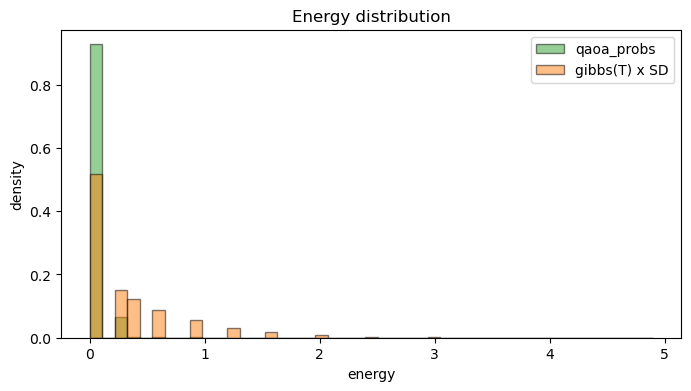

In [ ]:
# plot qaoa population and compare with custom temperature

# T = 2e5 * temp_formula
T = temp_formula

sd_eners = spectral_density(Q_norm, const_norm)
counts, bin_edges = np.histogram(sd_eners, bins=45, density=False)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]  # uniform bins
gibbs_factor = np.exp(-(bin_centers - np.min(bin_centers)) / T)
reweighted_counts = counts * gibbs_factor
reweighted_density = reweighted_counts / (np.sum(reweighted_counts) ) # divide by bin_width if you want a probability density


fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(111)

# ### plot QAOA samples
# bins_n = int((np.max(eners_qaoa_norm) - np.min(eners_qaoa_norm))/bin_width)
# ax.hist(eners_qaoa_norm, bins=bins_n, edgecolor="black", density=True, label = "qaoa_samples", alpha = .5)

### plot QAOA exact probs
n, _ = np.shape(Q_norm)
state_energies = np.array([evaluate_energy(state_inttobin(i, n), Q_norm, const_norm) for i in range(2**n)])
bins_n = int((np.max(state_energies) - np.min(state_energies))/bin_width)
ax.hist(state_energies, bins=bins_n, weights=probs_qaoa, density=False, edgecolor="black", color="C2", label="qaoa_probs", alpha=0.5)

### plot weighted spectral density
ax.bar(bin_centers, reweighted_density, width=bin_width, color = "C1", edgecolor="black", label = "gibbs(T) x SD", alpha = .5)

ax.set_title("Energy distribution")
ax.set_xlabel("energy")
ax.set_ylabel("density")
ax.legend()
plt.show()

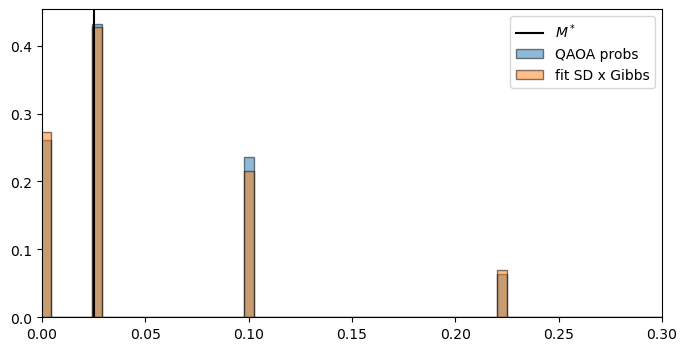

Temperatures:
from formula = 0.964	from fit = 0.114	circuit_effective temperature = 0.032


In [66]:
# compare with temperature fit

use_probs = True
sd_eners = spectral_density(Q_norm, const_norm)
temp_opt, bin_edges, model_hist, qaoa_hist, best_result = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 1000, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_width = bin_edges[1] - bin_edges[0]

# Plot comparison
fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(111)
if use_probs:
    ax.bar(bin_centers, qaoa_hist, width=bin_width, edgecolor="black", alpha=0.5, label="QAOA probs")
else:
    ax.bar(bin_centers, qaoa_hist, width=bin_width, edgecolor="black", alpha=0.5, label="QAOA samples")
M_norm_norm = results["M_star"] / (results["norm_guess"] * results["norm_final"])
ax.axvline(M_norm_norm, color = "k", label = r"$M^*$")
ax.bar(bin_centers, model_hist, width=bin_width, edgecolor="black", alpha=0.5, label=f"fit SD x Gibbs")
ax.set_xlim(0, .3)
ax.legend()
plt.show()

temp_circ_eff = temp_formula/ results["norm_final"]
print(f"Temperatures:\nfrom formula = {np.round(temp_formula, 3)}\tfrom fit = {np.round(temp_opt, 3)}\tcircuit_effective temperature = {np.round(temp_circ_eff, 3)}")


## Misc

### $T_{eff} (p)$

In [197]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "NPP"
vseed = 42
M_strategy = "feasibility"
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


N_idx = 0
layers_list = np.arange(1, 21)
temp_effective = np.ndarray((len(layers_list)))

for i, layers in enumerate(layers_list):
    results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)
    eners, temp_formula, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["temperature_norm"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
    eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

    # Renormalize energies
    norm_tot = norm_guess*norm_final
    Q_norm = Q/norm_tot
    const_norm = const/norm_tot
    eners_qaoa_norm = eners_qaoa/norm_tot

    # Get T_eff
    use_probs = True
    sd_eners = spectral_density(Q_norm, const_norm)
    temp_opt, bin_edges, model_hist, qaoa_hist, best_result = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 45, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
    temp_effective[i] = temp_opt

With an instance with 9 bits, 1 layers and (thus) est. temp. (UNnorm) 26473482.021 [norm -> 9.643], the appropriate M is 43577072.620391846
...breaking at iteration 89 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.382 	 eff_ex = 0.373		Scaling error (norm_final) = 15.907928637070126
One instance with size n_bits = 9 of NPP took 3.1253s

With an instance with 9 bits, 2 layers and (thus) est. temp. (UNnorm) 13236741.011 [norm -> 4.821], the appropriate M is 21919431.09035492
...breaking at iteration 169 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.881 	 eff_ex = 0.874		Scaling error (norm_final) = 8.019221622326546
One instance with size n_bits = 9 of NPP took 9.8145s

With an instance with 9 bits, 3 layers and (thus) est. temp. (UNnorm) 8824494.007 [norm -> 3.214], the appropriate M is 14697588.011622429
...breaking at iteration 169 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.93 	 eff_ex = 0.935		Scaling error (norm_final) = 5.388694929216337
One instance with size n_bits = 

/tmp/ipykernel_796533/2526408792.py:65: RuntimeWarning: overflow encountered in divide
  return float(np.sum(qaoa_prob[mask] * np.log(qaoa_prob[mask] / p[mask])))


With an instance with 9 bits, 5 layers and (thus) est. temp. (UNnorm) 5294696.404 [norm -> 1.929], the appropriate M is 8920951.068401337
...breaking at iteration 109 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.997 	 eff_ex = 0.998		Scaling error (norm_final) = 3.284578637864208
One instance with size n_bits = 9 of NPP took 13.6532s

With an instance with 9 bits, 6 layers and (thus) est. temp. (UNnorm) 4412247.004 [norm -> 1.607], the appropriate M is 7477824.449539185
...breaking at iteration 109 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.997 	 eff_ex = 0.997		Scaling error (norm_final) = 2.758925691508436
One instance with size n_bits = 9 of NPP took 15.9516s

With an instance with 9 bits, 7 layers and (thus) est. temp. (UNnorm) 3781926.003 [norm -> 1.378], the appropriate M is 6447957.0388793945
...breaking at iteration 259 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.994 	 eff_ex = 0.996		Scaling error (norm_final) = 2.3838007151595524
One instance with size n_bits =

Drawn fit:  beta = 13.563 p/n^(3/2)


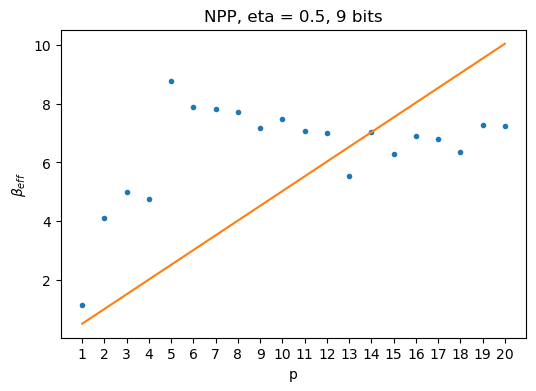

In [218]:
skip = 0

assert problem_type == "NPP"
n_bits = P*Ns[N_idx]

fun = lambda x, k : x*k / n_bits**(3/2)
coef, coef_std = sp.optimize.curve_fit(fun, layers_list[skip:], 1/temp_effective[skip:])
print(f"Drawn fit:  beta = {np.round(coef[0], 3)} p/n^(3/2)")

fig = plt.figure(figsize = (6, 4))
ax = fig.add_subplot(111)
ax.plot(layers_list, 1/temp_effective, ".")
xs = np.linspace(layers_list[skip], layers_list[-1], 100)
ax.plot(xs, fun(xs, *coef), "-", label = "fit")
ax.set_xlabel("p")
ax.set_ylabel(r"$\beta_{eff}$")
ax.set_xticks(layers_list)
ax.set_title(f"{problem_type}, eta = {eta_req}, {P*Ns[N_idx]} bits")
plt.show()

### Correlations?

In [15]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
vseed = 42
M_strategy = "feasibility"

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


N_idx_list = np.array([0, 1, 2])
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
nN, nl, ne = len(N_idx_list), len(layers_list), len(eta_req_list)
shape = (nN, nl, ne)

# pre-allocate scalar fields
log = {
    "temperature_formula":   np.zeros(shape),
    "temperature_effective": np.zeros(shape),
    "norm_guess":            np.zeros(shape),
    "norm_final":            np.zeros(shape),
    "M_star":                np.zeros(shape),
    "v_seed":                np.zeros(shape),
    "eta_eff_ex":                np.zeros(shape),
    "n_bits":                np.zeros(shape, dtype=int),
    # array fields: last axis is the variable-length dimension
    "energies_samples":      np.zeros(shape + (qaoa_samples,)),
    "probability_states":    [[[None]*ne for _ in range(nl)] for _ in range(nN)],  # ragged: kept as nested list
}

for i_N, N_idx in enumerate(N_idx_list):
    for i_l, layers in enumerate(layers_list):
        for i_e, eta_req in enumerate(eta_req_list):
            results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)
            eners, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
            eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

            # Renormalize energies
            norm_tot = norm_guess*norm_final
            Q_norm = Q/norm_tot
            const_norm = const/norm_tot
            eners_qaoa_norm = eners_qaoa/norm_tot

            # Get T_eff
            use_probs = True
            sd_eners = spectral_density(Q_norm, const_norm)
            temp_opt, _, _, _, _ = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 45, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
            results["temperature_effective"] = temp_opt

            # store
            idx = (i_N, i_l, i_e)
            log["temperature_formula"][idx]   = results["temperature_norm"]
            log["n_bits"][idx]                = results["n_bits"]
            log["eta_eff_ex"][idx]            = results["eta_eff_ex"]
            log["temperature_effective"][idx] = temp_opt
            log["norm_guess"][idx]            = norm_guess
            log["norm_final"][idx]            = norm_final
            log["M_star"][idx]                = M_star
            log["v_seed"][idx]                = vseed
            log["energies_samples"][idx]      = eners_qaoa_norm
            log["probability_states"][i_N][i_l][i_e] = probs_qaoa

file = open("./data_qaoa/corrs_PO.txt", "wb")
pickle.dump(log, file)
file.close()

With an instance with 6 bits, 5 layers, M* is 68.359375
...breaking at iteration 239 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.337
One instance with size n_bits = 6 of PO took 20.9485s

With an instance with 6 bits, 5 layers, M* is 281.93359375
...breaking at iteration 239 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.337
One instance with size n_bits = 6 of PO took 20.8023s

With an instance with 6 bits, 5 layers, M* is 600.9765625
...breaking at iteration 239 out of 500
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 0.336
One instance with size n_bits = 6 of PO took 20.5975s

With an instance with 6 bits, 10 layers, M* is 34.609375
...breaking at iteration 229 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.383
One instance with size n_bits = 6 of PO took 37.2941s

With an instance with 6 bits, 10 layers, M* is 140.4296875
...breaking at iteration 219 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.383
One instance with size n_bits = 6 of PO took 35.4662s

With 

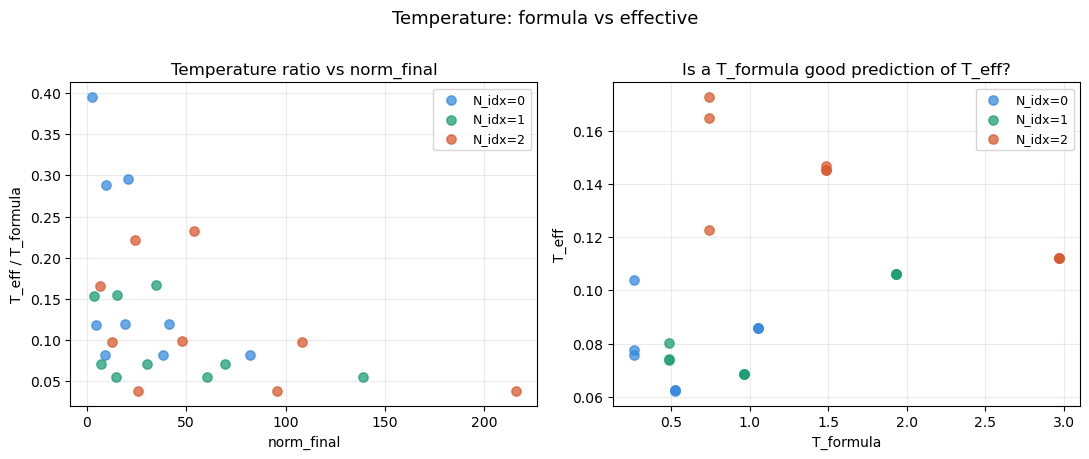

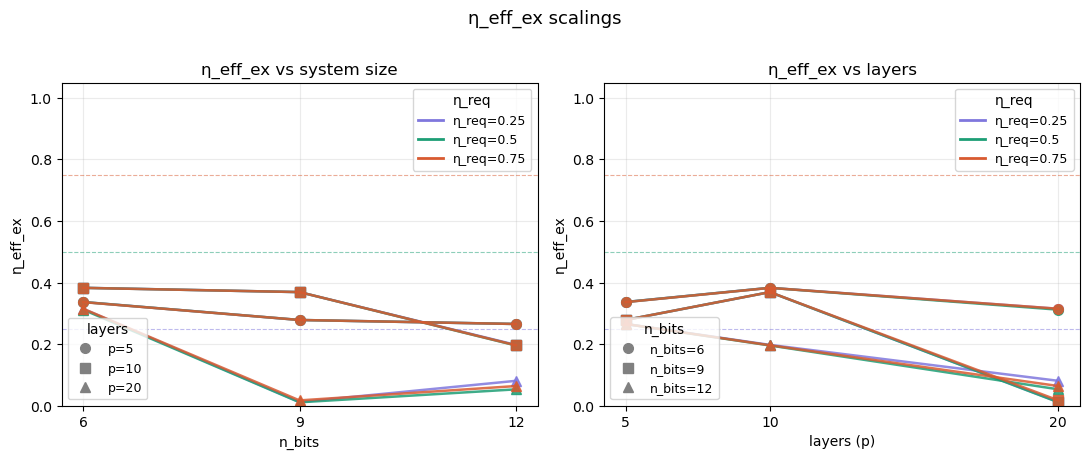

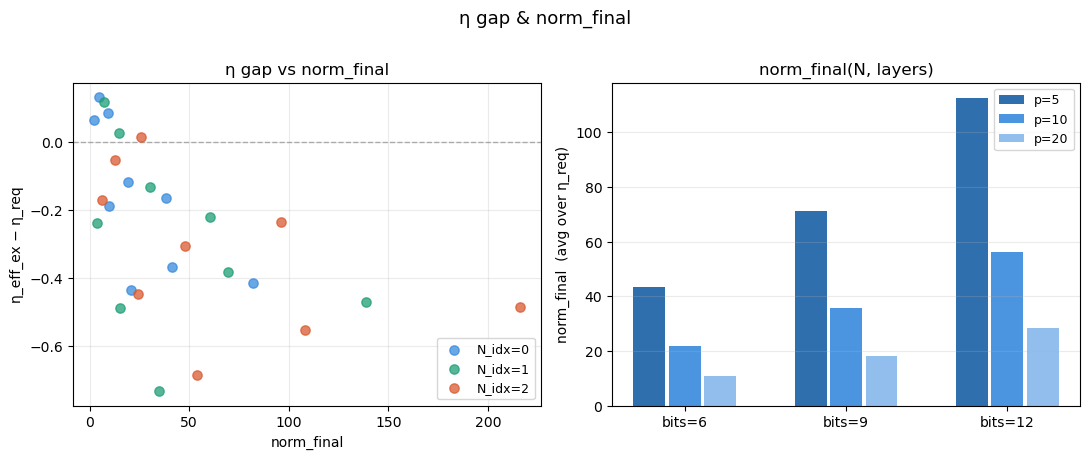

In [ ]:


# ── color palette (matches dashboard) ────────────────────────────────────────
COL_N    = ['#378ADD', '#1D9E75', '#D85A30']   # per N_idx
COL_ETA  = ['#7F77DD', '#1D9E75', '#D85A30']   # per eta_req
COL_L    = ['#185FA5', '#378ADD', '#85B7EB']    # per layers

# ── index lists (must match how log was built) ────────────────────────────────
N_idx_list   = np.array([0, 1, 2])
layers_list  = np.array([5, 10, 20])
eta_req_list = np.array([0.25, 0.50, 0.75])
nN, nl, ne   = len(N_idx_list), len(layers_list), len(eta_req_list)

# ── load your log here ────────────────────────────────────────────────────────
with open("./data_qaoa/corrs_PO.txt", "rb") as f:
    log = pickle.load(f)

temp_formula = log["temperature_formula"]   # shape (nN, nl, ne)
temp_eff     = log["temperature_effective"]
norm_final   = log["norm_final"]
eta_eff_ex   = log["eta_eff_ex"]


ratio      = temp_eff / temp_formula                          # (nN, nl, ne)
mismatch   = np.abs(temp_eff - temp_formula) / temp_formula  # (nN, nl, ne)
eta_gap    = eta_eff_ex - eta_req_list[np.newaxis, np.newaxis, :]  # (nN, nl, ne)


# Figure 1 — Temperature analysis
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 4.5))
fig1.suptitle("Temperature: formula vs effective", fontsize=13, fontweight='normal', y=1.01)

# --- panel 1a: T_eff/T_formula vs norm_final ---------------------------------
ax = axes1[0]
for i, ni in enumerate(N_idx_list):
    x = norm_final[i].ravel()
    y = ratio[i].ravel()
    ax.scatter(x, y, color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
x_range = [norm_final.min()*0.97, norm_final.max()*1.03]
# ax.axhline(1, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel("norm_final")
ax.set_ylabel("T_eff / T_formula")
ax.set_title("Temperature ratio vs norm_final")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# --- panel 1b: parity plot ---------------------------------------------------
ax = axes1[1]
all_t = np.concatenate([temp_eff.ravel(), temp_formula.ravel()])
tmin, tmax = all_t.min()*0.93, all_t.max()*1.05
for i, ni in enumerate(N_idx_list):
    ax.scatter(temp_formula[i].ravel(), temp_eff[i].ravel(),
               color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
# ax.plot([tmin, tmax], [tmin, tmax], color='gray', lw=1, ls='--', alpha=0.6, label='parity')
# ax.set_xlim(tmin, tmax)
# ax.set_ylim(tmin, tmax)
ax.set_xlabel("T_formula")
ax.set_ylabel("T_eff")
ax.set_title("Is a T_formula good prediction of T_eff?")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

fig1.tight_layout()


# Figure 2 — η_eff_ex scalings
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))
fig2.suptitle("η_eff_ex scalings", fontsize=13, fontweight='normal', y=1.01)

# --- panel 2a: η vs n_bits, per (eta_req, layers) ---------------------------
ax = axes2[0]
n_bits_list = np.array([6, 9, 12])
markers = {5: 'o', 10: 's', 20: '^'}

for k, er in enumerate(eta_req_list):
    for j, l in enumerate(layers_list):
        ax.plot(n_bits_list, eta_eff_ex[:, j, k],
                color=COL_ETA[k], marker=markers[l],
                lw=1.8, ms=7, alpha=0.85)
    ax.axhline(er, color=COL_ETA[k], lw=0.8, ls='--', alpha=0.5)

# two-part legend: color = η_req, marker = layers
from matplotlib.lines import Line2D
color_handles  = [Line2D([0], [0], color=COL_ETA[k], lw=2, label=f"η_req={er}")
                  for k, er in enumerate(eta_req_list)]
marker_handles = [Line2D([0], [0], color='gray', marker=markers[l], ls='',
                         ms=7, label=f"p={l}") for l in layers_list]
leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=9, title="η_req")
ax.add_artist(leg1)
ax.legend(handles=marker_handles, loc='lower left', fontsize=9, title="layers")

ax.set_xticks(n_bits_list)
ax.set_ylim(0, 1.05)
ax.set_xlabel("n_bits")
ax.set_ylabel("η_eff_ex")
ax.set_title("η_eff_ex vs system size")
ax.grid(True, alpha=0.25)

# --- panel 2b: η vs layers, per (eta_req, n_bits) ---------------------------
ax = axes2[1]
n_bits_list = np.array([6, 9, 12])
markers_N = {6: 'o', 9: 's', 12: '^'}

for k, er in enumerate(eta_req_list):
    for i, nb in enumerate(n_bits_list):
        ax.plot(layers_list, eta_eff_ex[i, :, k],
                color=COL_ETA[k], marker=markers_N[nb],
                lw=1.8, ms=7, alpha=0.85)
    ax.axhline(er, color=COL_ETA[k], lw=0.8, ls='--', alpha=0.5)

# two-part legend: color = η_req, marker = n_bits
from matplotlib.lines import Line2D
color_handles  = [Line2D([0], [0], color=COL_ETA[k], lw=2, label=f"η_req={er}")
                  for k, er in enumerate(eta_req_list)]
marker_handles = [Line2D([0], [0], color='gray', marker=markers_N[nb], ls='',
                         ms=7, label=f"n_bits={nb}") for nb in n_bits_list]
leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=9, title="η_req")
ax.add_artist(leg1)
ax.legend(handles=marker_handles, loc='lower left', fontsize=9, title="n_bits")

ax.set_xticks(layers_list)
ax.set_ylim(0, 1.05)
ax.set_xlabel("layers (p)")
ax.set_ylabel("η_eff_ex")
ax.set_title("η_eff_ex vs layers")
ax.grid(True, alpha=0.25)

fig2.tight_layout()


# Figure 3 — η gap & norm_final
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4.5))
fig3.suptitle("η gap & norm_final", fontsize=13, fontweight='normal', y=1.01)

# --- panel 3a: η gap vs norm_final scatter -----------------------------------
ax = axes3[0]
for i, ni in enumerate(N_idx_list):
    ax.scatter(norm_final[i].ravel(), eta_gap[i].ravel(),
               color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel("norm_final")
ax.set_ylabel("η_eff_ex − η_req")
ax.set_title("η gap vs norm_final")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# --- panel 3b: norm_final grouped bar (N × layers) --------------------------
ax = axes3[1]
norm_vs_NL = norm_final.mean(axis=2)   # (nN, nl) — averaged over eta_req
x = np.arange(nN)
width = 0.22
for j, l in enumerate(layers_list):
    offset = (j - 1) * width
    ax.bar(x + offset, norm_vs_NL[:, j], width=width*0.9,
           color=COL_L[j], label=f"p={l}", alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels([f"bits={n}" for n in [6,9,12]])
ax.set_ylabel("norm_final  (avg over η_req)")
ax.set_title("norm_final(N, layers)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')

fig3.tight_layout()


plt.show()

## $\eta_{eff}$ for problems, layers $p$ and $\eta_r$

### run QAOA

In [ ]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([0,1]) # 1,2 for TSP   0,1,2 for NPP    0,1,2,3 for PO
layers_list = np.array([5, 10, 20]) # [5, 10, 20]
eta_req_list = np.array([.25, .5, .75])
vseed_list = np.arange(42, 1042, 100) # 42-52 (TSP_rand), 52-62 (NPP), 42-942::100 (PO)

if problem_type == "PO":
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    n_bits_list = N_city_rand[N_idx_list]**2


# one file per (N_idx, vseed, layers, eta_req) combination
for vseed in vseed_list:
    for i, N_idx in enumerate(N_idx_list):
        n_bits = int(n_bits_list[i])
        for j, layers in enumerate(layers_list):
            for k, eta_req in enumerate(eta_req_list):
                # check if file already exists
                filename = f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt"
                if os.path.exists(filename):
                    print(filename, "  already exists, skipping")
                    continue

                info_instance = vseed
                if problem_type == "PO":
                    info_instance = (directory,  vseed)

                results = qaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)

                Q, const = results["QUBO"]
                Q = np.asarray(Q, float)
                assert Q.shape == (n_bits, n_bits), \
                    f"layers={layers}, eta_req={eta_req}: QUBO is {Q.shape}, expected {(n_bits, n_bits)}"

                # normalized QUBO actually trained by the circuit (pairs with best_pars);
                # reproduces the module's two-step scaling exactly (== Q/max(|Q|))
                Q_norm     = (Q     / results["s_conv"]) / results["norm_final"]
                const_norm = (const / results["s_conv"]) / results["norm_final"]

                res = {
                    "eta_eff":   float(results["eta_eff_ex"]),   # scalar
                    "best_pars": results["circuit_params"],      # single params array
                    "M_star":    float(results["M_star"]),       # scalar
                    "Q":            Q,                           # raw (n_bits, n_bits)
                    "Q_const":      float(const),                # raw scalar
                    "Q_norm":       Q_norm,                      # normalized (== Q/max(|Q|)), trained by circuit
                    "Q_const_norm": float(const_norm),           # normalized scalar
                    "vseed":     int(vseed),
                    "eta_req":   float(eta_req),
                    "layers":    int(layers),
                    "bits":      n_bits,
                }

                file = open(filename, "wb")
                pickle.dump(res, file)
                file.close()
                print(filename, "  written")

### run maQAOA

In [ ]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([0, 1, 2]) # 1,2 for TSP   0,1,2 for NPP    0,1,2,3 for PO
layers_list = np.array([1, 2, 3]) # [5, 10, 20]
eta_req_list = np.array([.25, .5, .75])
vseed_list = np.arange(642, 1042, 100) # 42-52 (TSP_rand), 52-62 (NPP), 42-942::100 (PO)

if problem_type == "PO":
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    n_bits_list = N_city_rand[N_idx_list]**2


# one file per (N_idx, vseed, layers, eta_req) combination
for vseed in vseed_list:
    for i, N_idx in enumerate(N_idx_list):
        n_bits = int(n_bits_list[i])
        for j, layers in enumerate(layers_list):
            for k, eta_req in enumerate(eta_req_list):
                # check if file already exists
                filename = f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt"
                if os.path.exists(filename):
                    print(filename, "  already exists, skipping")
                    continue

                info_instance = vseed
                if problem_type == "PO":
                    info_instance = (directory,  vseed)

                results = maqaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)

                Q, const = results["QUBO"]
                Q = np.asarray(Q, float)
                assert Q.shape == (n_bits, n_bits), \
                    f"layers={layers}, eta_req={eta_req}: QUBO is {Q.shape}, expected {(n_bits, n_bits)}"

                # normalized QUBO actually trained by the circuit (pairs with best_pars);
                # reproduces the module's two-step scaling exactly (== Q/max(|Q|))
                Q_norm     = (Q     / results["s_conv"]) / results["norm_final"]
                const_norm = (const / results["s_conv"]) / results["norm_final"]

                res = {
                    "eta_eff":   float(results["eta_eff_ex"]),   # scalar
                    "best_pars": results["circuit_params"],      # single params array
                    "M_star":    float(results["M_star"]),       # scalar
                    "Q":            Q,                           # raw (n_bits, n_bits)
                    "Q_const":      float(const),                # raw scalar
                    "Q_norm":       Q_norm,                      # normalized (== Q/max(|Q|)), trained by circuit
                    "Q_const_norm": float(const_norm),           # normalized scalar
                    "vseed":     int(vseed),
                    "eta_req":   float(eta_req),
                    "layers":    int(layers),
                    "bits":      n_bits,
                }

                file = open(filename, "wb")
                pickle.dump(res, file)
                file.close()
                print(filename, "  written")

...breaking at iteration 139 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 19.8651s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.25.txt   written
...breaking at iteration 139 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 18.8879s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.5.txt   written
...breaking at iteration 139 out of 500
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 18.2762s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.75.txt   written
...breaking at iteration 109 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.999
One instance with size n_bits = 9, 10 layers, of NPP took 28.1585s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_10_etareq_0.25.txt   written
...breaking at iteration 79 out of 500


KeyboardInterrupt: 

### joins datas

In [65]:
## create dics

Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
problem_type = "PO"



file = open("./data_qaoa/test1_PO_maqaoa.txt", "rb")
eta = pickle.load(file)
file.close()

n_idx_max, _, _ = np.shape(eta)
if problem_type == "PO":
    N_idx_list = np.arange(n_idx_max)
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    N_idx_list = np.arange(n_idx_max)
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    N_idx_list = np.arange(1, n_idx_max+1)
    n_bits_list = N_city_rand[N_idx_list]**2

layers_list = np.array([1,2,3])

res = {}
res["eta"] = eta
res["layers"] = layers_list
res["bits"] = n_bits_list

file = open("./data_qaoa/test1_PO_maqaoa_dic.txt", "wb")
pickle.dump(res, file)
file.close()

In [55]:
### join instances through layers

file = open("./data_qaoa/test1_TSP_rand.txt", "rb")
eta_base = pickle.load(file)
file.close()

file = open("./data_qaoa/test1_TSP_layer3.txt", "rb")
eta_ext = pickle.load(file)
file.close()

a,b,c = np.shape(eta_base)
eta = np.ndarray((a,b+1,c))

eta[:, 1:] = eta_base
eta[:, 0] = eta_ext[:,0]

file = open("./data_qaoa/test1_TSP_full.txt", "wb")
pickle.dump(eta, file)
file.close()

(2, 3, 3)
(2, 1, 3)
(2, 4, 3)


In [12]:
### join instances through N

file = open("./data_qaoa/test1_PO_layer3.txt", "rb")
eta_base = pickle.load(file)
file.close()
print(np.shape(eta_base))

file = open("./data_qaoa/test1_PO.txt", "rb")
eta_ext = pickle.load(file)
file.close()

a,b,c = np.shape(eta_base)
eta = np.ndarray((a+1,b,c))
eta[0] = eta_base
eta[1:] = eta_ext

file = open("./data_qaoa/test1_PO_full.txt", "wb")
pickle.dump(eta, file)
file.close()

(3, 1, 3)


ValueError: could not broadcast input array from shape (3,1,3) into shape (1,3)

### PO

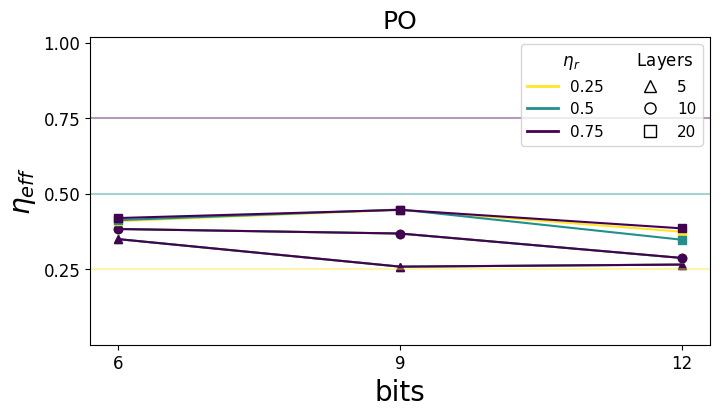

In [10]:
###### PORTFOLIO OPTIMIZATION

file = open("./data_qaoa/old_strategy/test1_PO.txt", "rb")
res = pickle.load(file)
file.close()

eta_eff_array = res["eta"]
layers_list = res["layers"]
n_bits_list = res["bits"]
problem_type = "PO"

markers = ["x", "^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    if j==0:
        continue
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        ax.plot(n_bits_list, y, "-", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")


# for j, layers in enumerate(layers_list):
#     for k, eta_req in enumerate(eta_req_list):
#         y = eta_eff_array_0[:, j, k]
#         ax.plot(n_bits_list, y, "--", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers[1:], layers_list[1:])]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}.pdf", bbox_inches='tight', format="pdf")

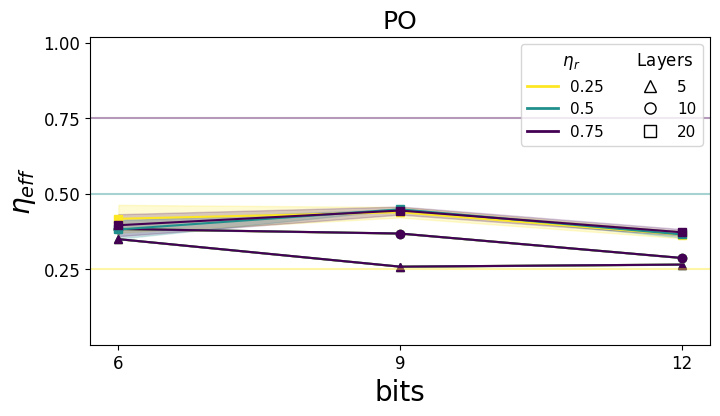

In [ ]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics

problem_type = "PO"
M_strategy = "feasibility"
vseed_list = np.arange(42, 1042, 100) # 42, 1042, 100 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([6, 9, 12])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

### NPP

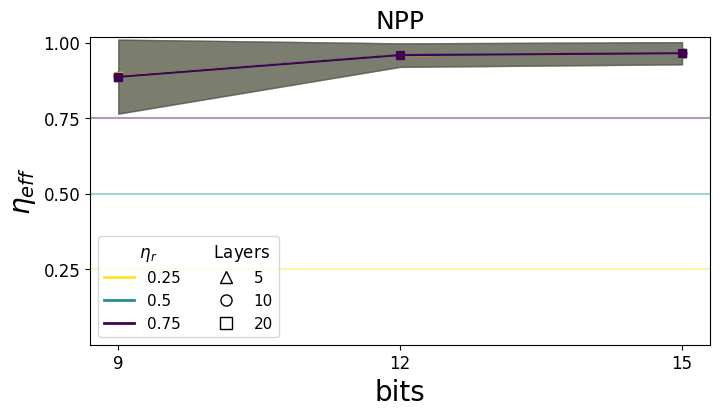

In [29]:
###### NUMBER PARTITION PROBLEM check MULTIPLE instances with statistics

problem_type = "NPP"
M_strategy = "optimality"
vseed_list = np.arange(52, 62)  # 52, 62 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([9, 12, 15])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=6, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="lower left", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
# ax.axhline(1, color = "k", alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

### TSP

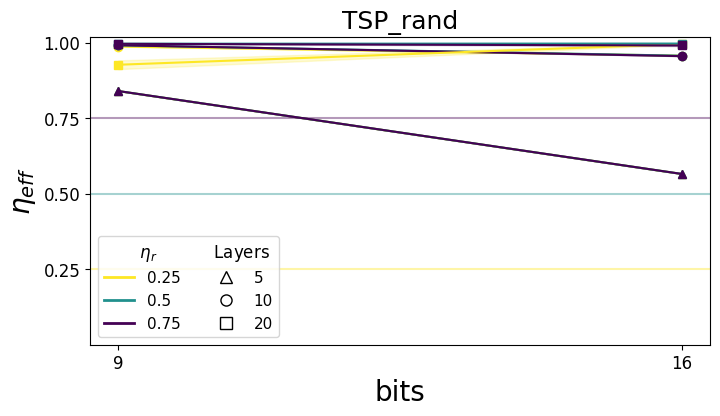

In [ ]:
###### TRAVELLING SALESMAN PROBLEM (random) check MULTIPLE instances with statistics

problem_type = "TSP_rand"
M_strategy = "feasibility"
vseed_list = np.arange(42, 52) # 42, 52 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([9, 16])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=6, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)
        
# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="lower left", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

## Compile optimized circuits

### code and one circuit

In [18]:
def build_qaoa_from_pars_pl(Q, num_qubits, p, params, n_samples=None, verbose=False):
    """
    Build (no optimisation) a PennyLane QAOA circuit from already-trained parameters,
    vanilla ansatz: |+>^n initial state + transverse-field (sum of X) mixer.

    Q          : (n,n) QUBO matrix — must be the SAME one the params were trained on.
    num_qubits : n.
    p          : QAOA depth.
    params     : flat length-2p array, order [gamma_0..gamma_{p-1}, beta_0..beta_{p-1}].
    Returns the same dict shape as the Dicke/XY version.
    """
    Q = np.asarray(Q, float)
    n = int(num_qubits)
    params = np.asarray(params, float).ravel()
    gammas, betas = params[:p], params[p:]

    # QUBO -> Ising (x_i = (1 - z_i)/2), identical convention to the Dicke version
    h = np.zeros(n); J = {}
    for i in range(n):
        h[i] += -Q[i, i] / 2
    for i in range(n):
        for j in range(i + 1, n):
            q = Q[i, j] + Q[j, i]
            J[(i, j)] = q / 4; h[i] += -q / 4; h[j] += -q / 4

    def state_prep():
        # |+>^n = uniform superposition over all 2^n computational basis states
        for i in range(n):
            qml.Hadamard(wires=i)

    def qaoa_layers(gammas=gammas, betas=betas):
        for L in range(p):
            for i in range(n):
                qml.RZ(2 * gammas[L] * h[i], wires=i)              # exp(-i gamma h_i Z_i)
            for (i, j), Jij in J.items():
                qml.IsingZZ(2 * gammas[L] * Jij, wires=[i, j])     # exp(-i gamma J_ij Z_iZ_j)
            for i in range(n):
                qml.RX(2 * betas[L], wires=i)                      # exp(-i beta X_i)

    def full_circuit():
        state_prep()
        qaoa_layers(gammas, betas)

    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def prob_node():
        full_circuit()
        return qml.probs(wires=range(n))

    probs = np.array(prob_node())
    best_idx = int(np.argmax(probs))
    best_x = [int(b) for b in format(best_idx, f"0{n}b")]
    if verbose:
        print(f"  Best x vector : {best_x}   P(best) = {probs[best_idx]:.4%}")

    ret = {"params": params, "probs": probs, "best_x": best_x,
           "circuit_fn": full_circuit, "state_prep_fn": state_prep, "qaoa_layers_fn": qaoa_layers}

    if n_samples is not None:
        dev_s = qml.device("default.qubit", wires=n, shots=n_samples)
        @qml.qnode(dev_s)
        def sample_node():
            full_circuit()
            return qml.counts(wires=range(n))
        ret["counts"] = sample_node()
    return ret




def Trans_qml_to_tket(full_circuit, n_qubits):
    """Translate a PennyLane Circuit direclty to a pytket Circuit"""
    tape = circuit_to_tape(full_circuit)
    
    # Gates we can translate directly
    translatable = {
        *SIMPLE_GATES, *TWO_QUBIT_GATES, *THREE_QUBIT_GATES,
        *ROTATIONS, *TWO_QUBIT_ROTATIONS, *CONTROLLED_ROTATIONS,
        "MultiControlledX", "QubitUnitary",
    }
    # Expand high-level gates (ApproxTimeEvolution, cost_layer, etc.)
    expanded = tape.expand(depth=10, stop_at=lambda op: op.name in translatable)
    
    circ = pCircuit(n_qubits)
    for op in expanded.operations:
        pennylane_op_to_tket(op, circ)
    return circ




def Compile_tket_locally_wbackend(
    circ,
    device_name="H2-2",
    optimisation_level=3,
    timeout=900,
    target_2qb_gate=OpType.ZZPhase,
    verbose=True,
):
    """
    Locally compile a pytket Circuit for Quantinuum H2 native gates.

    Native target:
        1q: PhasedX, Rz
        2q: ZZPhase by default

    This uses QuantinuumBackend.default_compilation_pass internally,
    so it is much better than manually calling generic pytket passes.
    """
    backend = QuantinuumBackend(device_name=device_name)
    backend.set_compilation_config_target_2qb_gate(target_2qb_gate) # preserve/use parameterized RZZ as native ZZPhase.

    before = {
        "total": circ.n_gates,
        "CX": circ.n_gates_of_type(OpType.CX),
        "TK1": circ.n_gates_of_type(OpType.TK1),
        "PhasedX": circ.n_gates_of_type(OpType.PhasedX),
        "Rz": circ.n_gates_of_type(OpType.Rz),
        "ZZPhase": circ.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": circ.n_gates_of_type(OpType.ZZMax),
        "TK2": circ.n_gates_of_type(OpType.TK2),
        "S": circ.n_gates_of_type(OpType.S),
        "Sdg": circ.n_gates_of_type(OpType.Sdg),
    }

    compiled = backend.get_compiled_circuit(
        circ,
        optimisation_level=optimisation_level,
        timeout=timeout,
    )

    after = {
        "total": compiled.n_gates,
        "CX": compiled.n_gates_of_type(OpType.CX),
        "TK1": compiled.n_gates_of_type(OpType.TK1),
        "PhasedX": compiled.n_gates_of_type(OpType.PhasedX),
        "Rz": compiled.n_gates_of_type(OpType.Rz),
        "ZZPhase": compiled.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": compiled.n_gates_of_type(OpType.ZZMax),
        "TK2": compiled.n_gates_of_type(OpType.TK2),
        "S": compiled.n_gates_of_type(OpType.S),
        "Sdg": compiled.n_gates_of_type(OpType.Sdg),
    }

    if verbose:
        print("Before:")
        for k, v in before.items():
            print(f"  {k:8s}: {v}")

        print("\nAfter:")
        for k, v in after.items():
            print(f"  {k:8s}: {v}")

        print("\nBackend valid:", backend.valid_circuit(compiled))

    if not backend.valid_circuit(compiled):
        print("\nInvalid circuit. Predicate diagnostics:")
        for pred in backend.required_predicates:
            ok = pred.verify(compiled)
            print(f"  {pred}: {ok}")

    return compiled

In [38]:
problem_type = "TSP_rand"
M_strategy = "feasibility"
n_bits = 9
vseed = 42
layers = 10
eta_req = 0.5

# get QUBO and QAOA pars
file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
res = pickle.load(file)
file.close()
best_pars = res["best_pars"]
Q_norm, const_norm = res["Q_norm"], res["Q_const_norm"]

# build circuit
res_circuit = build_qaoa_from_pars_pl(Q_norm, n_bits, layers, best_pars, n_samples=None)
pl_circuit = res_circuit["circuit_fn"]
probs_qaoa = res_circuit["probs"]

### check that simulating this circuit indeed returns the expected eta_eff_exact like in the training!
eta_eff_training = res["eta_eff"]
assert problem_type == "TSP_rand"
Nc = int(np.rint(np.sqrt(n_bits)))
Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
eta_eff_building = 0
if M_strategy == "feasibility":
    for i in range(2**n_bits):
        if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
            eta_eff_building += probs_qaoa[i]
print(f"Eta during training =\t{eta_eff_training}\nEta during building =\t{eta_eff_building}")

# compile circuit
tket_circ = Trans_qml_to_tket(pl_circuit , n_bits)
circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2, timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

# count credits
n_gates = (circ.n_1qb_gates(), circ.n_2qb_gates())
print(n_gates)
shots = 100
credits, n_shots = compute_credits(None, n_bits, n_gates[0], n_gates[1], shots = shots)
print(f"Cost = credits {credits:.2f} with (custom) {n_shots} number of shots")

Eta during training =	0.9914874783779335
Eta during building =	0.9914874783779666
(129, 360)
Cost = credits 81.38 with (custom) 100 number of shots


### Cost of ALL QAOA instances on Quantinuum hardware

In [ ]:
### Cost (in USD) of running ALL the optimized QAOA circuits on Quantinuum H2-2
# Sweeps every (problem_type, n_bits, layers, vseed) combination available in ./data_qaoa,
# at fixed M_strategy = "feasibility", eta_req = 0.5 and shots = 100.

import glob, re
import pandas as pd

M_strategy  = "feasibility"
eta_req     = 0.5
shots       = 100
usd_per_hqc = 1000 / 67          # 1000 USD buy 67 HQCs

layers_list = [5, 10, 20]
bits_dict   = {"PO": [6, 9, 12], "NPP": [9, 12, 15], "TSP_rand": [9, 16]}
# the 10 instances (vseed) of each family are read off the file names, so no need to hardcode them

records = []
for problem_type, bits_list in bits_dict.items():
    for n_bits in bits_list:
        for layers in layers_list:
            pattern = (f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}"
                       f"_bits_{n_bits}_vseed_*_layers_{layers}_etareq_{eta_req}.txt")
            files = sorted(glob.glob(pattern),
                           key=lambda f: int(re.search(r"_vseed_(\d+)_", f).group(1)))
            if len(files) == 0:
                print(f"!! no data for {problem_type} bits={n_bits} layers={layers}")
            for fname in tqdm.tqdm(files, desc=f"{problem_type} bits={n_bits} p={layers}", leave=False):
                vseed = int(re.search(r"_vseed_(\d+)_", fname).group(1))

                # get QUBO and QAOA pars
                file = open(fname, "rb")
                res = pickle.load(file)
                file.close()

                # build circuit
                res_circuit = build_qaoa_from_pars_pl(res["Q_norm"], n_bits, layers,
                                                      res["best_pars"], n_samples=None)

                # compile circuit
                tket_circ = Trans_qml_to_tket(res_circuit["circuit_fn"], n_bits)
                circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2,
                                                     timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

                # count credits
                n_1qb, n_2qb = circ.n_1qb_gates(), circ.n_2qb_gates()
                credits, n_shots = compute_credits(None, n_bits, n_1qb, n_2qb, shots=shots)

                records.append(dict(problem_type=problem_type, n_bits=n_bits, layers=layers, vseed=vseed,
                                    eta_eff=res["eta_eff"], n_1qb=n_1qb, n_2qb=n_2qb, shots=n_shots,
                                    HQC=credits, cost_usd=credits * usd_per_hqc))
            print(f"{problem_type:9s} bits={n_bits:2d} layers={layers:2d} -> {len(files):2d} instances done")

df_costs = pd.DataFrame.from_records(records)
df_costs.to_csv(f"./data_qaoa/qaoa_H2-2_costs_etareq_{eta_req}_shots_{shots}.csv", index=False)
print(f"\n{len(df_costs)} circuits priced.")

In [26]:
### Aggregated costs
import pandas as pd
df_costs = pd.read_csv("/tmp/claude-1000/-home-edo-Desktop-proj-hot-bigM-code/ca843476-b1f3-46e2-a3cf-262f824adde1/scratchpad/qaoa_costs.csv")

# cost of one circuit, broken down by (problem, size, depth): sum over the 10 instances + per-instance stats
print("=== USD per (problem_type, n_bits, layers), over the 10 instances ===")
print(df_costs.groupby(["problem_type", "n_bits", "layers"])["cost_usd"]
              .agg(sum_10_instances="sum", mean="mean", min="min", max="max", n="count")
              .round(2).to_string())

# cumulative (total) cost of each problem family, over ALL its combinations
print("\n=== TOTAL USD per problem type (all n_bits x layers x vseed) ===")
tot_usd = df_costs.groupby("problem_type")["cost_usd"].sum()
n_circ  = df_costs.groupby("problem_type")["cost_usd"].size()
for pt in ["PO", "NPP", "TSP_rand"]:
    print(f"  {pt:9s}: USD {tot_usd[pt]:12,.2f}   ({n_circ[pt]} circuits)")
print(f"  {'ALL':9s}: USD {df_costs['cost_usd'].sum():12,.2f}   ({len(df_costs)} circuits)")

=== USD per (problem_type, n_bits, layers), over the 10 instances ===
                            sum_10_instances     mean      min      max   n
problem_type n_bits layers                                                 
NPP          9      5                3898.51   389.85   373.73   391.64  10
                    10               6704.48   670.45   646.27   673.13  10
                    20              12334.33  1233.43  1217.31  1235.22  10
             12     5                5531.34   553.13   470.75   587.16  10
                    10              10133.73  1013.37   890.15  1051.94  10
                    20              19311.64  1931.16  1794.63  1983.28  10
             15     5                6777.91   677.79   549.55   746.87  10
                    10              13399.10  1339.91  1098.21  1511.34  10
                    20              26298.81  2629.88  2342.99  2755.52  10
PO           6      5                3319.40   331.94   331.94   331.94  10
                  

# PO analysis (optimiz. or reachability? INTERP and maQAOA)

## Scan M

### funcs for M scan and QAOA

In [ ]:
def Ml1_from_layers(problem_type, N_idx, info_instance, layers):
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")

    min_pfeas = .5
    temp = temperature_from_layers(layers, n_bits)
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temp, min_pfeas)
    return M_L1


def Mstar_l1_from_layers(problem_type, N_idx, info_instance, layers):
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")

    eta_req = .5

    ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
    temperature_normalized = temperature_from_layers(layers, n_bits)
    norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
    temperature_unnormalized = norm_guess * temperature_normalized

    beta = 1 / temperature_unnormalized
    min_pfeas = eta_req
    peak_max = 4 # 4 for NPP and TSP, 9 for PO
    if problem_type == "PO":
        E_LB = lower_bound_obj_PO(N, w, info_instance)
        peak_max = 25
    else:
        E_LB = 0
    ### assumed Mstrategy == "feasibility":
    M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)

    temp = temperature_unnormalized
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temp, min_pfeas)
    return M_star, M_L1




def qaoa_etaex_withM_alpha(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False, seed = 42):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")
    

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm


    mixer_weights = None
    if problem_type == "PO":
        # mixer_weights = N * [2**k for k in range(w-1, -1, -1)]
        mixer_weights = N * [2**k for k in range(w)]
        # print(mixer_weights)
    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, mixer_weights = mixer_weights, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)


    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]

    return eta_eff_exact #, eners


# ## NOTE: if this cvell breaks, uncommment this function and add _gamma 15 rows above
# def run_qaoa_with_solution_gamma(
#     qubo_dict: dict,
#     num_qubits: int,
#     p: int = 2,
#     steps: int = 150,
#     mixer_weights=None,             # NEW: array of length num_qubits; None → standard X-mixer
#     stepsize: float = 0.05,
#     n_samples: int = 1000,
#     seed: int | None = 42,
#     verbose: bool = True,
#     draw_samples: bool = True,
#     tolerance_opt:float = 1e-4,
# ) -> dict:
#     """
#     Run QAOA on a QUBO problem and return samples from the optimised circuit.

#     The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
#     Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

#     Args:
#         qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
#                      Diagonal entries (i==i) are linear coefficients.
#                      Off-diagonal entries can be upper-triangular or full;
#                      symmetric duplicates are handled correctly.
#         num_qubits : number of binary variables (= problem size n)
#         p          : QAOA depth — number of (cost + mixer) layer pairs
#         steps      : Adam optimisation steps
#         stepsize   : Adam learning rate
#         n_samples  : shots for final sampling from the optimised circuit
#         seed       : RNG seed for reproducibility (None = random)
#         verbose    : print cost every 10 steps

#     Returns a dict with keys:
#         "best_bitstring" : str   — bitstring of highest-probability basis state
#         "best_x"         : list  — binary vector corresponding to best_bitstring
#         "params"         : array — optimised [gammas, betas] of shape (2, p)
#         "counts"         : dict  — {bitstring: count} from n_samples shots
#         "cost_history"   : list  — cost value recorded every 10 steps
#     """

#     # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
#     # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
#     #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
#     #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

#     coeffs, obs = [], []
#     for (i, j), val in qubo_dict.items():
#         if i == j:
#             # Linear term
#             coeffs.append(-val / 2)
#             obs.append(qml.PauliZ(i))
#         else:
#             # Normalise so we always process the smaller index first
#             pair = (min(i, j), max(i, j))
#             coeffs.append(val / 4)
#             obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
#             coeffs.append(-val / 4)
#             obs.append(qml.PauliZ(pair[0]))
#             coeffs.append(-val / 4)
#             obs.append(qml.PauliZ(pair[1]))

#     cost_h  = qml.simplify( qml.dot(coeffs, obs) )
#     # ── 1b. Build mixer Hamiltonian ────────────────────────────────
#     if mixer_weights is None:
#         mixer_h = qaoa.x_mixer(range(num_qubits))
#     else:
#         w = np.asarray(mixer_weights, dtype=float)
#         if w.shape != (num_qubits,):
#             raise ValueError(
#                 f"mixer_weights must have length num_qubits={num_qubits}, "
#                 f"got shape {w.shape}"
#             )
#         if np.any(w <= 0):
#             raise ValueError("mixer_weights must be strictly positive")
#         # Normalise so mean(w) = 1 → overall mixing scale comparable to standard X-mixer
#         w_norm = w / np.mean(w)
#         mixer_h = qml.simplify(
#             qml.dot(w_norm.tolist(), [qml.PauliX(i) for i in range(num_qubits)])
#         )
#         if verbose:
#             print(f"  Weighted mixer: raw w = {w.tolist()}")
#             print(f"                  normalised w = {np.round(w_norm, 4).tolist()}")

#     # ── 2. Devices ────────────────────────────────────────────────────────────
#     dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

#     # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
#     def qaoa_ansatz(gammas, betas):
#         # Equal superposition starting state  |+⟩^n
#         for wire in range(num_qubits):
#             qml.Hadamard(wires=wire)
#         # Alternating cost / mixer layers
#         for layer in range(p):
#             qaoa.cost_layer(gammas[layer], cost_h)
#             qaoa.mixer_layer(betas[layer], mixer_h)

#     # ── 4. QNodes ─────────────────────────────────────────────────────────────
#     @qml.qnode(dev_sv)
#     def cost_node(params):
#         """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.expval(cost_h)

#     @qml.qnode(dev_sv)
#     def prob_node(params):
#         """Returns the full 2^n probability vector (exact, no shots)."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.probs(wires=range(num_qubits))
    
#     @qml.set_shots(shots=n_samples)
#     @qml.qnode(dev_sv)
#     def sample_node(params):
#         """Draws shots from the optimised circuit and returns counts."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.counts(wires=range(num_qubits))

#     # ── 5. Parameter initialisation — linear ramp heuristic ──────────────────
#     # Empirically good starting point: γ small→large, β large→small
#     rng    = np.random.default_rng(seed)
#     noise  = rng.uniform(-0.05, 0.05, size=(2, p))   # tiny noise to break symmetry

#     init_gammas = np.linspace(0.01, 1, p) + noise[0]
#     init_betas  = np.linspace(1, 0.01, p) + noise[1]
#     params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

#     # ── 6. Optimisation ───────────────────────────────────────────────────────
#     optimizer = qml.AdamOptimizer(stepsize=stepsize)
#     cost_history = []
#     best_params = None
#     best_cost = np.inf 

#     epsilon = tolerance_opt
#     step_check = 10
#     for step in range(steps):
#         params, cost_val = optimizer.step_and_cost(cost_node, params)
#         if cost_val < best_cost:
#             best_cost = cost_val
#             best_params = params.copy()

#         # cost_history.append(float(cost_val))
#         if (step + 1) % step_check == 0:
#             cost_history.append(float(cost_val))
#             if verbose:
#                 print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
#             if len(cost_history)>1:
#                 diff_10 = np.abs(cost_history[-2] - cost_history[-1])
#                 if diff_10 < epsilon:
#                     print(f"...breaking at iteration {step} out of {steps}")
#                     break


#     # ── 7. Draw samples (& extract best state)─────────────────────────────────
#     probs = np.array(prob_node(best_params))

#     # best_idx       = int(np.argmax(probs))
#     # best_bitstring = format(best_idx, f"0{num_qubits}b")
#     # best_x         = [int(b) for b in best_bitstring]
#     # if verbose:
#     #     print(f"\n  Best bitstring : {best_bitstring}")
#     #     print(f"  Best x vector  : {best_x}")
#     #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

#     params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
#     if draw_samples:
#         counts = sample_node(params)
#         return params, counts, probs
#     else:
#         return params, probs


### run

In [71]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
N_idx = 0
vseed = 142
M_strategy = "feasibility"
# layers = 10
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


layers_list = np.array([5, 10, 20])

# M_list = np.array([0, 1, 10, 100]) #, 110, 130, 150, 300])
# etaex_list = np.ndarray((len(M_list), len(layers_list)))

# M_num = 5
# etaex_list = np.ndarray((len(layers_list), M_num))
# Ms_lists = np.ndarray((len(layers_list), M_num))

Ml1 = Ml1_from_layers(problem_type, N_idx, info_instance, np.max(layers_list))

# M_list = np.geomspace(1, 100*Ml1, 9)
# M_list = np.concatenate((M_list[:2], M_list[4:]))
M_list = np.array([0, 1, 10])
etaex_list = np.ndarray((len(layers_list), len(M_list)))
for j, M in tqdm.tqdm(enumerate(M_list)):
    for i, layers in enumerate(layers_list):    
        etaex_list[i, j] = qaoa_etaex_withM_alpha(problem_type, N_idx, info_instance, M, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa = False)
        # eners_qaoa[i] = combine_obj_pen(eners, qaoa_samples, M_star)

0it [00:00, ?it/s]

...breaking at iteration 209 out of 500
...breaking at iteration 299 out of 500


1it [03:10, 190.84s/it]

...breaking at iteration 419 out of 500
...breaking at iteration 339 out of 500
...breaking at iteration 299 out of 500


2it [06:13, 185.98s/it]

...breaking at iteration 369 out of 500
...breaking at iteration 329 out of 500
...breaking at iteration 279 out of 500


3it [08:58, 179.50s/it]

...breaking at iteration 329 out of 500


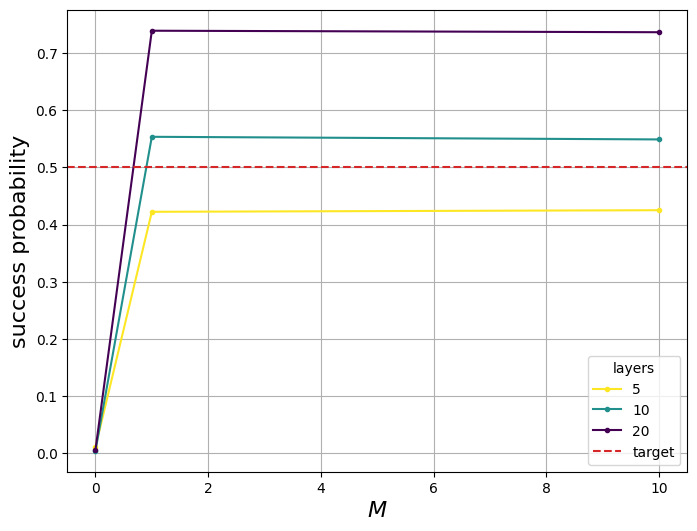

In [72]:
Mstar_list, Ml1_list = [], []
for layer in layers_list:
    a,b = Mstar_l1_from_layers(problem_type, N_idx, info_instance, layer)
    Mstar_list.append(a)
    Ml1_list.append(b)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111)

colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(layers_list)))) 
for i in range(len(layers_list)):
    # ax.plot(Ms_lists[i], etaex_list[i], ".-", label = layers_list[i], color = discr_colors.colors[i])
    ax.plot(M_list, etaex_list[i], ".-", label = layers_list[i], color = discr_colors.colors[i])
    # ax.axvline(Ml1_list[i], ls="-", color = discr_colors.colors[i])
    # ax.axvline(Mstar_list[i], ls="--", color = discr_colors.colors[i])
ax.set_xlabel(r"$M$", fontsize = 16)
# ax.set_ylabel(r"$\eta_{eff}$ exact", fontsize = 16)
ax.set_ylabel("success probability", fontsize = 16)
ax.axhline(0.5, ls ="--", color = "C3", label = "target")
# ax.set_xscale("log")
ax.grid()
ax.legend(title = "layers")
plt.show()

fig.savefig(f"qaoa_plots/{problem_type}_vseed{vseed}.pdf", format = "pdf")

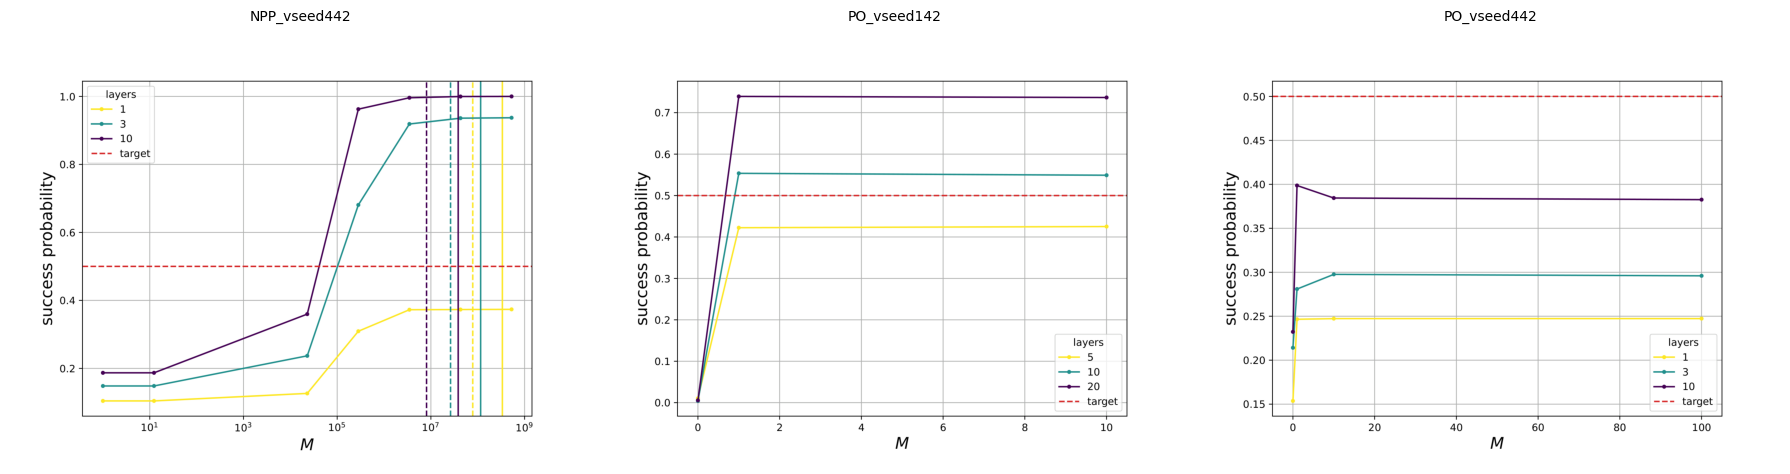

In [4]:
import matplotlib.pyplot as plt, fitz, io, glob
from PIL import Image as PILImage

def pdf_to_img(path, dpi=200):
    pix = fitz.open(path)[0].get_pixmap(dpi=dpi)
    return PILImage.open(io.BytesIO(pix.tobytes("png")))

paths = ["qaoa_plots/NPP_vseed442.pdf",
         "qaoa_plots/PO_vseed142.pdf",
         "qaoa_plots/PO_vseed442.pdf"]

fig, axes = plt.subplots(1, len(paths), figsize=(6*len(paths), 5))
for ax, p in zip(axes, paths):
    ax.imshow(pdf_to_img(p))
    ax.axis("off")
    ax.set_title(p.split("/")[-1].replace(".pdf", ""), fontsize=10)
plt.tight_layout()
plt.show()

## Run with random initialization (is the saturation only due to optimization [rand $\ge$ linear] or is it due to reachability/expressibility [rand $\approx$ linear]?)

#### code

In [ ]:
def run_qaoa_randinit(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt:float = 1e-4,
) -> dict:
    """
    Run QAOA on a QUBO problem and return samples from the optimised circuit.

    The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
    Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

    Args:
        qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
                     Diagonal entries (i==i) are linear coefficients.
                     Off-diagonal entries can be upper-triangular or full;
                     symmetric duplicates are handled correctly.
        num_qubits : number of binary variables (= problem size n)
        p          : QAOA depth — number of (cost + mixer) layer pairs
        steps      : Adam optimisation steps
        stepsize   : Adam learning rate
        n_samples  : shots for final sampling from the optimised circuit
        seed       : RNG seed for reproducibility (None = random)
        verbose    : print cost every 10 steps

    Returns a dict with keys:
        "best_bitstring" : str   — bitstring of highest-probability basis state
        "best_x"         : list  — binary vector corresponding to best_bitstring
        "params"         : array — optimised [gammas, betas] of shape (2, p)
        "counts"         : dict  — {bitstring: count} from n_samples shots
        "cost_history"   : list  — cost value recorded every 10 steps
    """

    # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
    # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
    #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
    #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j:
            # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else:
            # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))

    cost_h  = qml.simplify( qml.dot(coeffs, obs) )
    mixer_h = qaoa.x_mixer(range(num_qubits))

    # ── 2. Devices ────────────────────────────────────────────────────────────
    dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

    # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
    def qaoa_ansatz(gammas, betas):
        # Equal superposition starting state  |+⟩^n
        for wire in range(num_qubits):
            qml.Hadamard(wires=wire)
        # Alternating cost / mixer layers
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)
            qaoa.mixer_layer(betas[layer], mixer_h)

    # ── 4. QNodes ─────────────────────────────────────────────────────────────
    @qml.qnode(dev_sv)
    def cost_node(params):
        """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
        qaoa_ansatz(params[0], params[1])
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(params):
        """Returns the full 2^n probability vector (exact, no shots)."""
        qaoa_ansatz(params[0], params[1])
        return qml.probs(wires=range(num_qubits))
    
    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(params):
        """Draws shots from the optimised circuit and returns counts."""
        qaoa_ansatz(params[0], params[1])
        return qml.counts(wires=range(num_qubits))

    # ── 5. Parameter initialisation — totally random initial pars ──────────────────
    # Empirically good starting point: γ small→large, β large→small
    rng    = np.random.default_rng(seed)
    rand  = rng.uniform(0, 1, size=(2, p))

    init_gammas = rand[0]
    init_betas  = rand[1]
    params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

    # ── 6. Optimisation ───────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_params = None
    best_cost = np.inf 

    epsilon = tolerance_opt
    step_check = 10
    for step in range(steps):
        params, cost_val = optimizer.step_and_cost(cost_node, params)
        if cost_val < best_cost:
            best_cost = cost_val
            best_params = params.copy()

        # cost_history.append(float(cost_val))
        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
            if len(cost_history)>1:
                diff_10 = np.abs(cost_history[-2] - cost_history[-1])
                if diff_10 < epsilon:
                    print(f"...breaking at iteration {step} out of {steps}")
                    break


    # ── 7. Draw samples (& extract best state)─────────────────────────────────
    probs = np.array(prob_node(best_params))

    # best_idx       = int(np.argmax(probs))
    # best_bitstring = format(best_idx, f"0{num_qubits}b")
    # best_x         = [int(b) for b in best_bitstring]
    # if verbose:
    #     print(f"\n  Best bitstring : {best_bitstring}")
    #     print(f"  Best x vector  : {best_x}")
    #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

    params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
    if draw_samples:
        counts = sample_node(params)
        return params, counts, probs
    else:
        return params, probs
    



def qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, seed = 42, print_time = True, verbose_qaoa = False):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")
    
    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa = run_qaoa_randinit(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)

    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]
    return eta_eff_exact #, eners

#### run

In [ ]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 442
layers = 10

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e7 # 1e2 for PO and 1e7 for NPP 

n_rand_tries = 20
etaex_list = np.ndarray((n_rand_tries))
for i in tqdm.tqdm(range(n_rand_tries)):
    etaex_list[i] = qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa = False, seed = i)

print(etaex_list)

 10%|█         | 2/20 [02:48<23:41, 78.97s/it] 

...breaking at iteration 229 out of 500


 15%|█▌        | 3/20 [03:58<21:13, 74.89s/it]

...breaking at iteration 309 out of 500


 20%|██        | 4/20 [05:08<19:22, 72.69s/it]

...

...breaking at iteration 439 out of 500


 95%|█████████▌| 19/20 [23:59<01:27, 87.24s/it]

...breaking at iteration 449 out of 500


100%|██████████| 20/20 [25:31<00:00, 76.59s/it]

...breaking at iteration 419 out of 500
[0.99781013 0.9977765  0.99965954 0.99676626 0.99626866 0.99926448
 0.99948068 0.99872481 0.99838897 0.99640377 0.99860897 0.9986251
 0.99540991 0.99772674 0.99836089 0.99896104 0.99823493 0.99816701
 0.99939135 0.99924093]


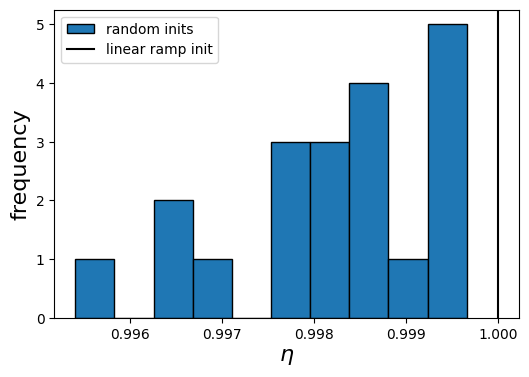

In [46]:
fig = plt.figure(figsize = (6,4))
ax = fig.add_subplot(111)
ax.hist(etaex_list, label = "random inits", density=False, edgecolor="black", color="C0")
ax.axvline(1, label = "linear ramp init", color = "k")
ax.set_xlabel(r"$\eta$", fontsize = 16)
ax.set_ylabel("frequency", fontsize = 16)
# ax.set_xscale("log")
ax.legend()
plt.show()

fig.savefig(f"qaoa_plots/randominits_{problem_type}.pdf", format = "pdf")

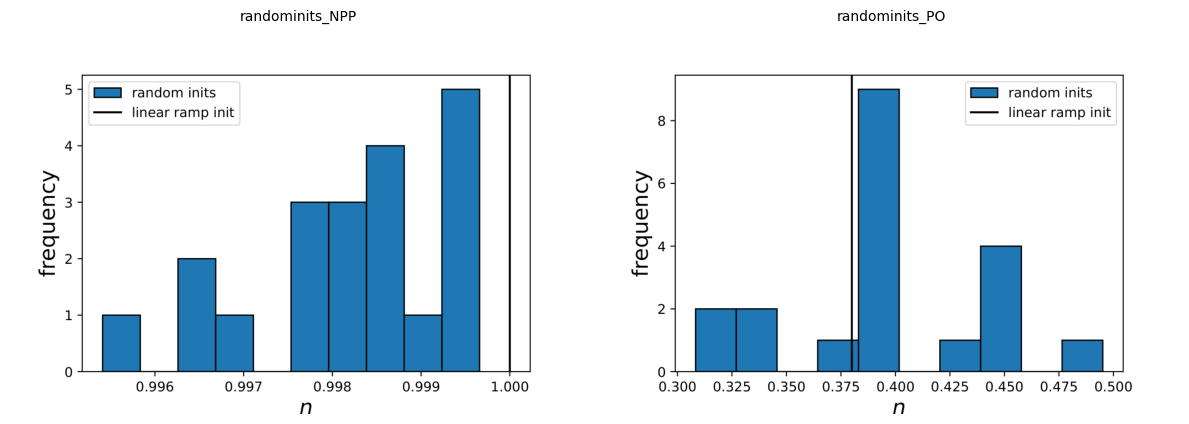

In [5]:
import matplotlib.pyplot as plt, fitz, io, glob
from PIL import Image as PILImage

def pdf_to_img(path, dpi=200):
    pix = fitz.open(path)[0].get_pixmap(dpi=dpi)
    return PILImage.open(io.BytesIO(pix.tobytes("png")))

paths = ["qaoa_plots/randominits_NPP.pdf",
         "qaoa_plots/randominits_PO.pdf"]

fig, axes = plt.subplots(1, len(paths), figsize=(6*len(paths), 5))
for ax, p in zip(axes, paths):
    ax.imshow(pdf_to_img(p))
    ax.axis("off")
    ax.set_title(p.split("/")[-1].replace(".pdf", ""), fontsize=10)
plt.tight_layout()
plt.show()

## Reachability scaling 1: success vs layers at saturation M

In [53]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 442
# layers = 10
layers_list = np.array([1,2,3,5,7,10,15,20,30])

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e2 # 1e2 for PO and 1e7 for NPP 

n_tries = 5
etaex_list = np.ndarray((len(layers_list), n_tries))
for i, layers in tqdm.tqdm(enumerate(layers_list)):
    for j in range(n_tries):
        etaex_list[i, j] = qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa = False, seed = j)

0it [00:00, ?it/s]

...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500


1it [00:08,  8.71s/it]

...breaking at iteration 69 out of 500
...breaking at iteration 239 out of 500
...breaking at iteration 189 out of 500
...breaking at iteration 239 out of 500
...breaking at iteration 259 out of 500


2it [00:52, 29.08s/it]

...

...breaking at iteration 289 out of 500
...breaking at iteration 279 out of 500
...breaking at iteration 449 out of 500
...breaking at iteration 219 out of 500
...breaking at iteration 209 out of 500


8it [24:38, 299.84s/it]

...breaking at iteration 439 out of 500
...breaking at iteration 409 out of 500
...breaking at iteration 99 out of 500
...breaking at iteration 389 out of 500
...breaking at iteration 139 out of 500


9it [33:33, 223.68s/it]

...breaking at iteration 109 out of 500


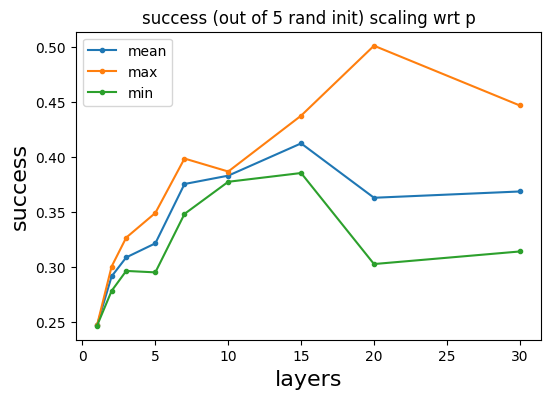

In [ ]:
fig = plt.figure(figsize = (6,4))
ax = fig.add_subplot(111)
ax.plot(layers_list, np.mean(etaex_list, axis=-1), ".-", label = "mean")
ax.plot(layers_list, np.max(etaex_list, axis=-1), ".-", label = "max")
ax.plot(layers_list, np.min(etaex_list, axis=-1), ".-", label = "min")
ax.set_xlabel("layers", fontsize = 16)
ax.set_ylabel("success", fontsize = 16)
ax.set_title("success (out of 5 rand init) scaling wrt p")
# ax.set_xscale("log")
ax.legend()
plt.show()

# fig.savefig(f"qaoa_plots/p-scaling_{problem_type}.pdf", format = "pdf")

## Transfering schedules INTERP to alleviate optimization

#### code

In [ ]:
from pennylane import qaoa


def interp_step(params_p):
    """
    Single INTERP step (Zhou et al. 2018): from depth p to depth p+1.

    Formula (1-indexed math):
        x_i^[p+1] = (i-1)/p · x_{i-1}^[p] + (p-i+1)/p · x_i^[p],   i = 1, ..., p+1
        x_0^[p] = x_{p+1}^[p] = 0

    In 0-indexed Python:
        new[:, i] = (i/p) · params_p[:, i-1] + ((p-i)/p) · params_p[:, i]

    Args:
        params_p : array of shape (2, p) — [gammas, betas]
    Returns:
        array of shape (2, p+1) — warm-start guess
    """
    params_p = np.asarray(params_p, dtype=float)
    p = params_p.shape[1]
    new = np.zeros((2, p + 1))
    for i in range(p + 1):
        if i > 0:
            new[:, i] += (i / p) * params_p[:, i - 1]
        if i < p:
            new[:, i] += ((p - i) / p) * params_p[:, i]
    return new





# def run_qaoa_with_solution(
#     qubo_dict: dict,
#     num_qubits: int,
#     p: int = 2,
#     init_params=None,            # NEW: warm-start, shape (2, p); None → linear ramp + noise
#     steps: int = 150,
#     stepsize: float = 0.05,
#     n_samples: int = 1000,
#     seed: int | None = 42,
#     verbose: bool = True,
#     draw_samples: bool = True,
#     tolerance_opt: float = 1e-4,
# ):
#     # ── 1. Ising cost Hamiltonian (unchanged) ───────────────────────────────
#     coeffs, obs = [], []
#     for (i, j), val in qubo_dict.items():
#         if i == j:
#             coeffs.append(-val / 2);  obs.append(qml.PauliZ(i))
#         else:
#             pair = (min(i, j), max(i, j))
#             coeffs.append( val / 4);  obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
#             coeffs.append(-val / 4);  obs.append(qml.PauliZ(pair[0]))
#             coeffs.append(-val / 4);  obs.append(qml.PauliZ(pair[1]))
#     cost_h  = qml.simplify(qml.dot(coeffs, obs))
#     mixer_h = qaoa.x_mixer(range(num_qubits))

#     # ── 2. Device / QNodes (unchanged) ──────────────────────────────────────
#     dev_sv = qml.device("default.qubit", wires=num_qubits)

#     def qaoa_ansatz(gammas, betas):
#         for wire in range(num_qubits):
#             qml.Hadamard(wires=wire)
#         for layer in range(p):
#             qaoa.cost_layer(gammas[layer], cost_h)
#             qaoa.mixer_layer(betas[layer], mixer_h)

#     @qml.qnode(dev_sv)
#     def cost_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.expval(cost_h)

#     @qml.qnode(dev_sv)
#     def prob_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.probs(wires=range(num_qubits))

#     @qml.set_shots(shots=n_samples)
#     @qml.qnode(dev_sv)
#     def sample_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.counts(wires=range(num_qubits))

#     # ── 3. Parameter init (CHANGED) ─────────────────────────────────────────
#     if init_params is not None:
#         init_params = np.asarray(init_params, dtype=float)
#         if init_params.shape != (2, p):
#             raise ValueError(
#                 f"init_params shape {init_params.shape} doesn't match (2, p) = (2, {p})"
#             )
#         params = pl_np.array(init_params.copy(), requires_grad=True)
#     else:
#         rng   = np.random.default_rng(seed)
#         noise = rng.uniform(-0.05, 0.05, size=(2, p))
#         init_gammas = np.linspace(0.01, 1, p) + noise[0]
#         init_betas  = np.linspace(1, 0.01, p) + noise[1]
#         params = pl_np.array([init_gammas, init_betas], requires_grad=True)

#     # ── 4. Optimisation (unchanged) ─────────────────────────────────────────
#     optimizer = qml.AdamOptimizer(stepsize=stepsize)
#     cost_history = []
#     best_params, best_cost = None, np.inf
#     epsilon, step_check = tolerance_opt, 10

#     for step in range(steps):
#         params, cost_val = optimizer.step_and_cost(cost_node, params)
#         if cost_val < best_cost:
#             best_cost   = cost_val
#             best_params = params.copy()
#         if (step + 1) % step_check == 0:
#             cost_history.append(float(cost_val))
#             if verbose:
#                 print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
#             if len(cost_history) > 1 and abs(cost_history[-2] - cost_history[-1]) < epsilon:
#                 if verbose:
#                     print(f"...breaking at iteration {step} out of {steps}")
#                 break

#     # ── 5. Outputs (CHANGED: now also returns best_cost) ────────────────────
#     probs = np.array(prob_node(best_params))
#     params_final = np.array(best_params)
#     if draw_samples:
#         counts = sample_node(params_final)
#         return params_final, counts, probs, float(best_cost)
#     else:
#         return params_final, probs, float(best_cost)
    




def run_qaoa_interp(
    Q_dict,
    n_bits,
    p_max,
    p_record=None,
    n_perturbations=5,
    perturbation_scale=0.05,
    qaoa_steps=500,
    stepsize=0.05,
    seed=42,
    verbose=False,
):
    """
    INTERP scheduling (Zhou et al. 2018) from p=1 to p=p_max.

    At p=1: n_perturbations linear-ramp+noise inits.
    At p>1: INTERP-step from the best params at p-1, perturb n_perturbations times,
            optimise each, keep best for propagation.

    Returns: dict {p: {"best_params", "best_cost", "best_probs",
                       "all_params", "all_costs", "all_probs"}} for p in p_record.
    """
    if p_record is None:
        p_record = list(range(1, p_max + 1))
    p_record_set = set(p_record)

    rng = np.random.default_rng(seed)
    results = {}
    best_params_running = None

    for p in range(1, p_max + 1):
        # Build warm-start base
        warm_start = None if p == 1 else interp_step(best_params_running)  # shape (2, p)

        all_params, all_probs, all_costs = [], [], []
        for k in range(n_perturbations):
            if warm_start is None:
                # p=1: use the inner function's default linear-ramp+noise via seed
                init = None
                inner_seed = int(seed) * 10_000 + p * 100 + k
            else:
                noise = rng.uniform(-perturbation_scale, perturbation_scale, size=(2, p))
                init = warm_start + noise
                inner_seed = None  # unused when init_params is given

            params_k, probs_k, cost_k = run_qaoa_with_solution(
                Q_dict, n_bits,
                p=p,
                init_params=init,
                steps=qaoa_steps,
                stepsize=stepsize,
                seed=inner_seed if inner_seed is not None else 0,
                verbose=False,
                draw_samples=False,
            )
            all_params.append(params_k)
            all_probs.append(probs_k)
            all_costs.append(cost_k)

        # Propagate the best (by cost) to the next level
        best_idx = int(np.argmin(all_costs))
        best_params_running = all_params[best_idx]

        if verbose:
            print(f"[INTERP] p={p:>2d}  best cost={all_costs[best_idx]:+.4f}  "
                  f"spread={max(all_costs)-min(all_costs):.4f}")

        if p in p_record_set:
            results[p] = {
                "best_params": all_params[best_idx],
                "best_cost":   all_costs[best_idx],
                "best_probs":  all_probs[best_idx],
                "all_params":  all_params,
                "all_probs":   all_probs,
                "all_costs":   all_costs,
            }

    return results



def qaoa_etaex_withM_interp(
    problem_type, N_idx, info_instance, M,
    p_max=30, p_record=None, n_perturbations=5,
    qaoa_steps=500, verbose=False, seed=42,
):
    # ── 1. Build penalty Q (for feasibility check) and total Q ──────────────
    if problem_type == "NPP":
        N = Ns[N_idx];  n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q, const         = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx];  n_bits = Nc**2
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q, const         = get_QUBO_TSP(Nc, M, None, "circle")
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx];  n_bits = Nc**2
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q, const         = get_QUBO_TSP(Nc, M, info_instance, "seed")
    elif problem_type == "PO":
        N = N_stocks[N_idx];  n_bits = N * w
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, "seed", info_instance, penalization=True, objective=False)
        Q, const         = get_QUBO_PO(N, w, M, "seed", info_instance)
    else:
        raise ValueError("Unknown problem_type")

    # Normalise Q
    norm   = np.max(np.abs(Q))
    Q_norm = Q / norm
    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)}

    # ── 2. INTERP ──────────────────────────────────────────────────────────
    results = run_qaoa_interp(
        Q_dict, n_bits,
        p_max=p_max,
        p_record=p_record,
        n_perturbations=n_perturbations,
        qaoa_steps=qaoa_steps,
        seed=seed,
        verbose=verbose,
    )

    # ── 3. Feasibility (success) per p, per init ───────────────────────────
    def success_from_probs(probs):
        s = 0.0
        for i in range(2 ** n_bits):
            pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
            if np.isclose(pen_en, 0):
                s += probs[i]
        return s

    success_best, success_all = {}, {}
    for p, res in results.items():
        success_best[p] = success_from_probs(res["best_probs"])
        success_all[p]  = [success_from_probs(pr) for pr in res["all_probs"]]

    return success_best, success_all

#### run [reachability scaling 2: with interp]

In [ ]:
problem_type   = "PO"
N_idx          = 0
vseed          = 442
directory      = "PO_small"
info_instance  = (directory, vseed) if problem_type == "PO" else vseed
M              = 1e2                       # 1e2 for PO, 1e7 for NPP

p_max          = 30
p_record       = [1, 2, 3, 5, 7, 10, 15, 20, 30]
n_perturbations = 2

success_best, success_all = qaoa_etaex_withM_interp(
    problem_type, N_idx, info_instance, M,
    p_max=p_max, p_record=p_record, n_perturbations=n_perturbations,
    qaoa_steps=300, verbose=True, seed=vseed,
)

[INTERP] p= 1  best cost=-0.1854  spread=0.0000
[INTERP] p= 2  best cost=-0.2130  spread=0.0000
[INTERP] p= 3  best cost=-0.2227  spread=0.0001
[INTERP] p= 4  best cost=-0.2293  spread=0.0000
[INTERP] p= 5  best cost=-0.2360  spread=0.0000
[INTERP] p= 6  best cost=-0.2467  spread=0.0000
[INTERP] p= 7  best cost=-0.2488  spread=0.0001
[INTERP] p= 8  best cost=-0.2495  spread=0.0002
[INTERP] p= 9  best cost=-0.2499  spread=0.0003
[INTERP] p=10  best cost=-0.2536  spread=0.0008
[INTERP] p=11  best cost=-0.2557  spread=0.0000
[INTERP] p=12  best cost=-0.2549  spread=0.0011
[INTERP] p=13  best cost=-0.2585  spread=0.0021
[INTERP] p=14  best cost=-0.2596  spread=0.0054
[INTERP] p=15  best cost=-0.2609  spread=0.0006
[INTERP] p=16  best cost=-0.2608  spread=0.0034
[INTERP] p=17  best cost=-0.2606  spread=0.0004
[INTERP] p=18  best cost=-0.2619  spread=0.0008
[INTERP] p=19  best cost=-0.2615  spread=0.0001
[INTERP] p=20  best cost=-0.2624  spread=0.0001
[INTERP] p=21  best cost=-0.2623  spread

<Figure size 600x400 with 0 Axes>

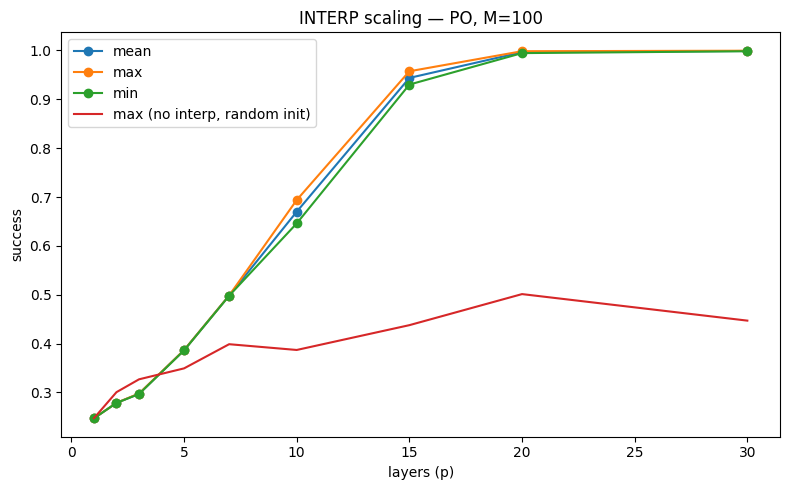

In [69]:
# ── Plot mean / min / max across the n_perturbations at each recorded p ────
import matplotlib.pyplot as plt

ps   = sorted(success_best.keys())
mean = [np.mean(success_all[p]) for p in ps]
mn   = [np.min(success_all[p])  for p in ps]
mx   = [np.max(success_all[p])  for p in ps]


fig = plt.figure(figsize = (6,4))

ax.set_xlabel("layers", fontsize = 16)
ax.set_ylabel("success", fontsize = 16)
ax.set_title("success (out of 5 rand init) scaling wrt p")
# ax.set_xscale("log")
ax.legend()


fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
ax.plot(ps, mean, "-o", label="mean")
ax.plot(ps, mx,   "-o", label="max")
ax.plot(ps, mn,   "-o", label="min")
ax.plot(ps, np.max(etaex_list, axis=-1), label = "max (no interp, random init)")
ax.set_xlabel("layers (p)")
ax.set_ylabel("success")
ax.set_title(f"INTERP scaling — {problem_type}, M={M:g}")
ax.legend()
plt.tight_layout()
plt.show()


fig.savefig(f"qaoa_plots/p-scaling_INTERP_{problem_type}.pdf", format = "pdf")

## testing thermal property of large M limit

#### code

In [ ]:
def qaoa_etaex_withM_beta(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False, seed = 42):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")
    

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)


    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]

    dic_tmp = {}
    dic_tmp["probs"] = probs_qaoa
    dic_tmp["penalization"] = (Q_pen, const_pen)
    dic_tmp["objective"] = (Q_obj, const_obj)
    dic_tmp["norm"] = norm

    return eta_eff_exact, dic_tmp



def thermal_prediction(n_bits, Q, const, norm, layers, idxs_sort):
    ener = np.ndarray((2**n_bits))
    for i in range(2**n_bits):
        ener[i] = evaluate_energy(state_inttobin(i, n_bits), Q, const)
    ener /= norm

    temp = .1 * temperature_from_layers(layers, n_bits)
    prob = np.exp(-ener/temp)
    prob /= np.sum(prob)

    return prob[idxs_sort]

#### run

In [138]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
N_idx = 0
vseed = 142
M_strategy = "feasibility"
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

layers_list = np.array([1, 10, 20])
n_bits = w * N_stocks[N_idx]
M = 1e20

probs_qaoa_sort = np.ndarray((len(layers_list), 2**n_bits))
predict_pen = np.ndarray((len(layers_list), 2**n_bits))
predict_tot = np.ndarray((len(layers_list), 2**n_bits))
for k, layers in enumerate(layers_list):
    etaex, dic = qaoa_etaex_withM_beta(problem_type, N_idx, info_instance, M, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa = False)

    probs_qaoa = dic["probs"]
    (Q_pen, const_pen) = dic["penalization"]
    (Q_obj, const_obj) = dic["objective"]
    norm_used = dic["norm"]

    pens = np.ndarray((2**n_bits))
    # objs = np.ndarray((2**n_bits))
    for i in range(2**n_bits):
        pens[i] = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        # objs[i] = evaluate_energy(state_inttobin(i, n_bits), Q_obj, const_obj)
    idxs_pen = np.argsort(pens)
    pens_sorted = pens[idxs_pen]
    probs_qaoa_sort[k] = probs_qaoa[idxs_pen]
    predict_pen[k] = thermal_prediction(n_bits, Q_pen, const_pen, norm = np.max(np.abs(Q_pen)), layers = layers, idxs_sort = idxs_pen)
    predict_tot[k] = thermal_prediction(n_bits, Q_obj+M*Q_pen, const_obj+M*const_pen, norm = norm_used, layers = layers, idxs_sort = idxs_pen)

# idxs_prob = np.argsort(probs_qaoa)[::-1]
# print("State \t\t\t pen \t prob \t\t obj")
# for i in idxs_prob:
#     print(state_inttobin(i, n_bits), "\t", pens[i], "\t", np.round(probs_qaoa[i], 5), "\t", np.round(objs[i], 5))

...breaking at iteration 69 out of 500
...breaking at iteration 269 out of 500
...breaking at iteration 399 out of 500


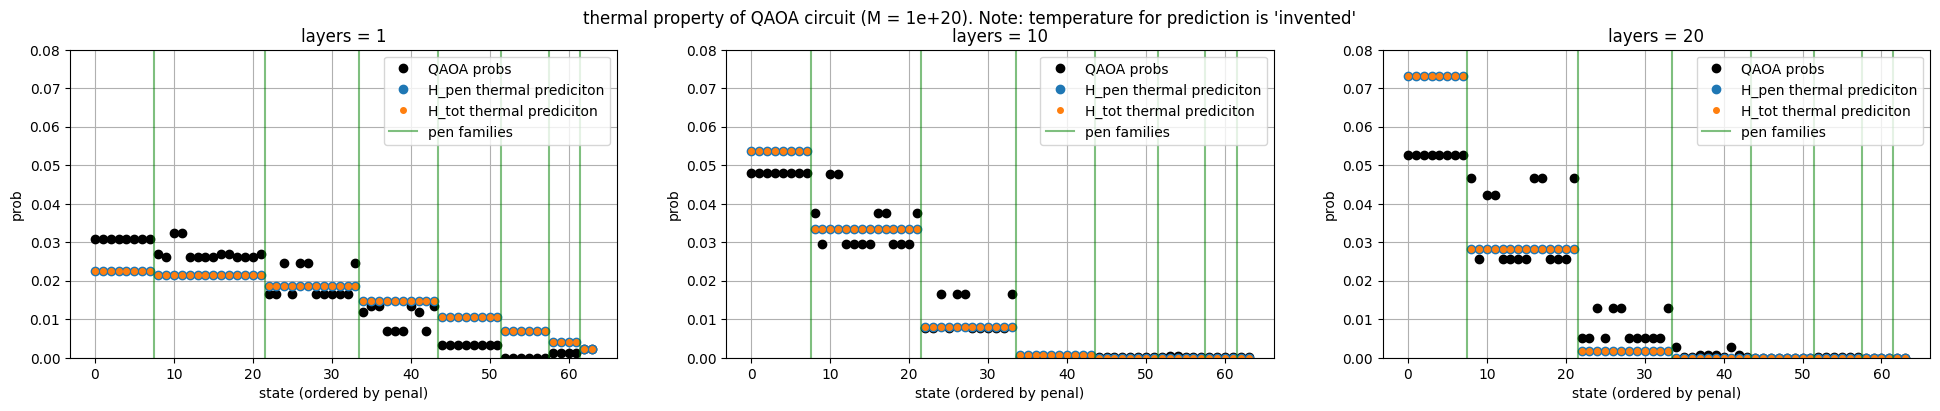

In [139]:

fig = plt.figure(figsize = (8*len(layers_list),4))
fig.suptitle(f"thermal property of QAOA circuit (M = {M}). Note: temperature for prediction is 'invented'")

for k in range(len(layers_list)):
    ax = fig.add_subplot(1, len(layers_list), k+1)
    ax.plot(np.arange(len(probs_qaoa_sort[k])), probs_qaoa_sort[k], "o", label = "QAOA probs", color = "black")
    ax.plot(np.arange(len(predict_pen[k])), predict_pen[k], "o", label = "H_pen thermal prediciton", color = "C0")
    ax.plot(np.arange(len(predict_tot[k])), predict_tot[k], "o", label = "H_tot thermal prediciton", color = "C1", markersize = 4)
    dividers = np.where( (pens_sorted[1:] - pens_sorted[:-1]) > .1 )[0]
    for d in dividers[:-1]:
        ax.axvline(d+.5, alpha = .5, color = "g")
    ax.axvline(dividers[-1]+.5, alpha = .5, color = "g", label = "pen families")
    ax.set_xlabel("state (ordered by penal)")
    ax.set_ylabel("prob")
    ax.set_title(f"layers = {layers_list[k]}")
    ax.set_ylim(0, .08)
    ax.legend(loc = "upper right")
    ax.grid()

## ma-QAOA to boost circuit expressivity (for PO)

#### code

In [ ]:
def run_ma_qaoa_with_solution(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    init_params=None,
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt: float = 1e-4,
    patience: int = 3,                # NEW: require N consecutive small diffs to stop
):
    """
    Multi-angle QAOA (ma-QAOA), Herrman et al. 2022.

    Each unique Pauli term in H_C gets its own γ per layer.
    Each qubit gets its own β per layer.
    """

    # ── 1. Aggregate QUBO into unique Pauli terms ───────────────────────────
    single_z, double_zz = {}, {}
    for (i, j), val in qubo_dict.items():
        if i == j:
            single_z[i] = single_z.get(i, 0.0) + (-val / 2)
        else:
            pair = (min(i, j), max(i, j))
            double_zz[pair]   = double_zz.get(pair, 0.0) + (val / 4)
            single_z[pair[0]] = single_z.get(pair[0], 0.0) + (-val / 4)
            single_z[pair[1]] = single_z.get(pair[1], 0.0) + (-val / 4)

    single_z  = {i: c for i, c in single_z.items()  if not np.isclose(c, 0.0)}
    double_zz = {pr: c for pr, c in double_zz.items() if not np.isclose(c, 0.0)}
    single_terms = sorted(single_z.items())
    double_terms = sorted(double_zz.items())
    n_single = len(single_terms)
    n_double = len(double_terms)
    n_gammas = n_single + n_double
    n_betas  = num_qubits

    if verbose:
        print(f"  ma-QAOA: n_gammas = {n_gammas} ({n_single} Z + {n_double} ZZ), "
              f"n_betas = {n_betas}, total params = {p * (n_gammas + n_betas)}")

    coeffs_all, obs_all = [], []
    for i, c in single_terms:
        coeffs_all.append(c);  obs_all.append(qml.PauliZ(i))
    for (i, j), c in double_terms:
        coeffs_all.append(c);  obs_all.append(qml.PauliZ(i) @ qml.PauliZ(j))
    cost_h = qml.simplify(qml.dot(coeffs_all, obs_all))

    # ── 2. Device & ansatz ──────────────────────────────────────────────────
    dev_sv = qml.device("default.qubit", wires=num_qubits)

    def ma_qaoa_ansatz(gammas, betas):
        for w_ in range(num_qubits):
            qml.Hadamard(wires=w_)
        for layer in range(p):
            for k, (i, coeff) in enumerate(single_terms):
                qml.RZ(2 * gammas[layer, k] * coeff, wires=i)
            for k, ((i, j), coeff) in enumerate(double_terms):
                qml.IsingZZ(2 * gammas[layer, n_single + k] * coeff, wires=[i, j])
            for i in range(num_qubits):
                qml.RX(2 * betas[layer, i], wires=i)

    # ── 3. QNodes — γ and β as SEPARATE positional args (key fix) ───────────
    @qml.qnode(dev_sv)
    def cost_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.probs(wires=range(num_qubits))

    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.counts(wires=range(num_qubits))

    # ── 4. Init ─────────────────────────────────────────────────────────────
    if init_params is not None:
        gammas_init, betas_init = init_params
        gammas_init = np.asarray(gammas_init, dtype=float)
        betas_init  = np.asarray(betas_init,  dtype=float)
        if gammas_init.shape != (p, n_gammas):
            raise ValueError(f"init gammas shape {gammas_init.shape} != ({p},{n_gammas})")
        if betas_init.shape != (p, n_betas):
            raise ValueError(f"init betas shape {betas_init.shape} != ({p},{n_betas})")
    else:
        rng = np.random.default_rng(seed)
        ramp_gamma = np.linspace(0.01, 1.0, p)
        ramp_beta  = np.linspace(1.0, 0.01, p)
        gammas_init = np.broadcast_to(ramp_gamma[:, None], (p, n_gammas)).copy()
        betas_init  = np.broadcast_to(ramp_beta[:, None],  (p, n_betas )).copy()
        gammas_init += rng.uniform(-0.05, 0.05, size=gammas_init.shape)
        betas_init  += rng.uniform(-0.05, 0.05, size=betas_init.shape)

    # Two SEPARATE trainable tensors (NOT a list)
    gammas = pl_np.array(gammas_init, requires_grad=True)
    betas  = pl_np.array(betas_init,  requires_grad=True)

    # ── 4b. Sanity check: confirm gradients are non-zero at init ────────────
    if verbose:
        grad_fn = qml.grad(cost_node, argnum=[0, 1])
        g_gamma, g_beta = grad_fn(gammas, betas)
        print(f"  init grad norms: ||∂C/∂γ|| = {np.linalg.norm(g_gamma):.4e}, "
              f"||∂C/∂β|| = {np.linalg.norm(g_beta):.4e}")

    # ── 5. Optimisation ─────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_gammas, best_betas, best_cost = None, None, np.inf
    epsilon, step_check = tolerance_opt, 10
    small_diff_count = 0   # for patience-based early stop

    for step in range(steps):
        (gammas, betas), cost_val = optimizer.step_and_cost(cost_node, gammas, betas)
        if cost_val < best_cost:
            best_cost   = cost_val
            best_gammas = gammas.copy()
            best_betas  = betas.copy()

        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step+1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
            if len(cost_history) > 1:
                if abs(cost_history[-2] - cost_history[-1]) < epsilon:
                    small_diff_count += 1
                else:
                    small_diff_count = 0
                if small_diff_count >= patience:
                    if verbose:
                        print(f"...converged at step {step+1} "
                              f"({patience} consecutive diffs < {epsilon})")
                    break

    # ── 6. Outputs ──────────────────────────────────────────────────────────
    probs = np.array(prob_node(best_gammas, best_betas))
    final_gammas = np.array(best_gammas)
    final_betas  = np.array(best_betas)
    if draw_samples:
        counts = sample_node(final_gammas, final_betas)
        return (final_gammas, final_betas), counts, probs, float(best_cost)
    else:
        return (final_gammas, final_betas), probs, float(best_cost)










# ### OLD maQAOA
# def maqaoa_sampling(problem_type, N_idx, info_instance, Mstrategy, eta_required, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
#     """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
#      Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
#     t1 = timer()
    
#     ### 1. Get LCBO
#     if problem_type == "NPP":
#         N = Ns[N_idx]
#         size = (N, P)
#         n_bits = N * P
#         Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
#         info_type = "seed"
#         problem_type_Mfunc = "NPP"
#     elif problem_type == "TSP_circle":
#         Nc = N_city_circle[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_instance = None
#         info_type = "circle"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "TSP_rand":
#         Nc = N_city_rand[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "PO":
#         N = N_stocks[N_idx]
#         size = (N, w)
#         n_bits = N*w
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
#         problem_type_Mfunc = "PO"
#     else:
#         raise ValueError("What problem are we solving?")
    
#     ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
#     temperature_normalized = temperature_from_layers(layers, n_bits)
#     norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
#     temperature_unnormalized = norm_guess * temperature_normalized

#     beta = 1 / temperature_unnormalized
#     min_pfeas = eta_required  # eta
#     peak_max = 4 # 4 for NPP and TSP, 9 for PO
#     if problem_type == "PO":
#         E_LB = lower_bound_obj_PO(N, w, info_instance)
#         peak_max = 25
#     else:
#         E_LB = 0
#     if Mstrategy == "optimality":
#         E_f = select_Ef(problem_type, N_idx)
#         M_star, eta_guaranteed = M_method_opt(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_f, E_LB, log_stable = True)
#     elif Mstrategy == "feasibility":
#         M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)
#     M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temperature_unnormalized, min_pfeas)
#     # print(f"With an instance with {n_bits} bits, {layers} layers and (thus) est. temp. (UNnorm) {np.round(temperature_unnormalized, 3)} [norm -> {np.round(temperature_normalized, 3)}], the appropriate M is {M_star}")
#     # print(f"With an instance with {n_bits} bits, {layers} layers, M* is {M_star}, M_L1 is {M_L1}")

#     ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
#     if problem_type == "NPP":
#         Q, const = get_QUBO_NPP(N, P, M_star, info_instance)
#     elif problem_type[:3] == "TSP":
#         Q, const = get_QUBO_TSP(Nc, M_star, info_instance, info_type)
#     elif problem_type == "PO":
#         Q, const = get_QUBO_PO(N, w, M_star, info_type, info_instance)
#     else:
#         raise ValueError("What problem are we solving?")

#     # Normalizing Q according to the temperature scaling we did in step 2
#     Q_norm, const_norm = Q/norm_guess, const/norm_guess

#     ## Re-normalizing Q
#     norm_final = np.max(np.abs(Q_norm))
#     Q_norm, const_norm = Q_norm/norm_final, const_norm/norm_final

#     Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
#     params_ma, probs_ma = run_ma_qaoa_with_solution(
#         Q_dict, n_bits,
#         p=layers,                 # try small p first; expressivity per layer is much higher
#         steps=qaoa_steps,
#         n_samples=qaoa_samples,
#         verbose=verbose_qaoa,
#         draw_samples=True,

#         seed=442,
#     )

#     eta_eff_exact = 0
#     for i in range(2**n_bits):
#         if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
#             eta_eff_exact += probs_ma[i]
#     print(f"Etas: req = {np.round(eta_required, 3)} \t gua = {np.round(eta_guaranteed, 3)} \t eff_ex = {np.round(eta_eff_exact, 3)}")

#     t2 = timer()
#     if print_time:
#         print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")
#     return eta_eff_exact 



### normalized temperature and pipeline



# def maqaoa_sampling_withM(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
#     """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
#      Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
#     t1 = timer()
    
#     ### 1. Get LCBO
#     if problem_type == "NPP":
#         N = Ns[N_idx]
#         size = (N, P)
#         n_bits = N * P
#         Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
#         info_type = "seed"
#         problem_type_Mfunc = "NPP"
#     elif problem_type == "TSP_circle":
#         Nc = N_city_circle[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_instance = None
#         info_type = "circle"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "TSP_rand":
#         Nc = N_city_rand[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "PO":
#         N = N_stocks[N_idx]
#         size = (N, w)
#         n_bits = N*w
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
#         problem_type_Mfunc = "PO"
#     else:
#         raise ValueError("What problem are we solving?")


#     ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
#     if problem_type == "NPP":
#         Q, const = get_QUBO_NPP(N, P, M, info_instance)
#     elif problem_type[:3] == "TSP":
#         Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
#     elif problem_type == "PO":
#         Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
#     else:
#         raise ValueError("What problem are we solving?")

#     ## Normalizing Q
#     norm = np.max(np.abs(Q))
#     Q_norm, const_norm = Q/norm, const/norm

#     Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
#     params_ma, probs_ma = run_ma_qaoa_with_solution(
#         Q_dict, n_bits,
#         p=layers,                 # try small p first; expressivity per layer is much higher
#         steps=qaoa_steps,
#         verbose=verbose_qaoa,
#         draw_samples=False,
#         seed=442,
#     )

#     eta_eff_exact = 0
#     for i in range(2**n_bits):
#         if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
#             eta_eff_exact += probs_ma[i]

#     t2 = timer()
#     if print_time:
#         print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")

#     return eta_eff_exact

#### run one instance

In [18]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 342
layers = 2

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e2
etaex = maqaoa_sampling_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa=True)
print(etaex)

  ma-QAOA: n_gammas = 21 (6 Z + 15 ZZ), n_betas = 6, total params = 54
  init grad norms: ||∂C/∂γ|| = 8.0776e-02, ||∂C/∂β|| = 3.7265e-01


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  step   10/500  |  cost = -0.160384
  step   20/500  |  cost = -0.179767
  step   30/500  |  cost = -0.194673
  step   40/500  |  cost = -0.214313
  step   50/500  |  cost = -0.229461
  step   60/500  |  cost = -0.237963
  step   70/500  |  cost = -0.241679
  step   80/500  |  cost = -0.243892
  step   90/500  |  cost = -0.245357
  step  100/500  |  cost = -0.246399
  step  110/500  |  cost = -0.247349
  step  120/500  |  cost = -0.248370
  step  130/500  |  cost = -0.249524
  step  140/500  |  cost = -0.250692
  step  150/500  |  cost = -0.251823
  step  160/500  |  cost = -0.252947
  step  170/500  |  cost = -0.254013
  step  180/500  |  cost = -0.254956
  step  190/500  |  cost = -0.255751
  step  200/500  |  cost = -0.256398
  step  210/500  |  cost = -0.256913
  step  220/500  |  cost = -0.257326
  step  230/500  |  cost = -0.257669
  step  240/500  |  cost = -0.257971
  step  250/500  |  cost = -0.258250
  step  260/500  |  cost = -0.258514
  step  270/500  |  cost = -0.258763
 

## ma-QAOA big test for PO

#### code and run

In [26]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([3])
layers_list = np.array([1,2,3])
eta_req_list = np.array([.25, .5, .75])
vseed = 142

eta_eff_array = np.ndarray((len(N_idx_list), len(layers_list), len(eta_req_list)))
for i, N_idx in enumerate(N_idx_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            info_instance = vseed
            if problem_type == "PO":
                info_instance = (directory,  vseed)
            eta_eff_array[i,j,k] = maqaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa=True)

file = open("./data_qaoa/test1_PO_maqaoa_3.txt", "wb")
pickle.dump(eta_eff_array, file)
file.close()

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 135


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 4.7188e+00, ||∂C/∂β|| = 1.2162e-01
  step   10/500  |  cost = -3.087791
  step   20/500  |  cost = -3.257474
  step   30/500  |  cost = -3.261182
  step   40/500  |  cost = -3.298820
  step   50/500  |  cost = -3.320873
  step   60/500  |  cost = -3.336480
  step   70/500  |  cost = -3.348692
  step   80/500  |  cost = -3.356286
  step   90/500  |  cost = -3.360271
  step  100/500  |  cost = -3.362780
  step  110/500  |  cost = -3.364688
  step  120/500  |  cost = -3.366167
  step  130/500  |  cost = -3.367445
  step  140/500  |  cost = -3.368603
  step  150/500  |  cost = -3.369668
  step  160/500  |  cost = -3.370646
  step  170/500  |  cost = -3.371535
  step  180/500  |  cost = -3.372335
  step  190/500  |  cost = -3.373043
  step  200/500  |  cost = -3.373664
  step  210/500  |  cost = -3.374203
  step  220/500  |  cost = -3.374670
  step  230/500  |  cost = -3.375076
  step  240/500  |  cost = -3.375434
  step  250/500  |  cost = -3.375759
  step  2

/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 4.7188e+00, ||∂C/∂β|| = 1.2162e-01
  step   10/500  |  cost = -3.087802
  step   20/500  |  cost = -3.257484
  step   30/500  |  cost = -3.261191
  step   40/500  |  cost = -3.298832
  step   50/500  |  cost = -3.320889
  step   60/500  |  cost = -3.336494
  step   70/500  |  cost = -3.348707
  step   80/500  |  cost = -3.356299
  step   90/500  |  cost = -3.360283
  step  100/500  |  cost = -3.362790
  step  110/500  |  cost = -3.364698
  step  120/500  |  cost = -3.366176
  step  130/500  |  cost = -3.367454
  step  140/500  |  cost = -3.368612
  step  150/500  |  cost = -3.369677
  step  160/500  |  cost = -3.370655
  step  170/500  |  cost = -3.371545
  step  180/500  |  cost = -3.372344
  step  190/500  |  cost = -3.373053
  step  200/500  |  cost = -3.373675
  step  210/500  |  cost = -3.374215
  step  220/500  |  cost = -3.374682
  step  230/500  |  cost = -3.375089
  step  240/500  |  cost = -3.375448
  step  250/500  |  cost = -3.375774
  step  2

...

  init grad norms: ||∂C/∂γ|| = 7.8104e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929175
  step   20/500  |  cost = -3.238987
  step   30/500  |  cost = -3.308704
  step   40/500  |  cost = -3.354141
  step   50/500  |  cost = -3.376059
  step   60/500  |  cost = -3.395484
  step   70/500  |  cost = -3.405332
  step   80/500  |  cost = -3.409004
  step   90/500  |  cost = -3.410735
  step  100/500  |  cost = -3.411584
  step  110/500  |  cost = -3.411922
  step  120/500  |  cost = -3.412152
  step  130/500  |  cost = -3.412266
  step  140/500  |  cost = -3.412331
  step  150/500  |  cost = -3.412370
  step  160/500  |  cost = -3.412396
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.0922s

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 405


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 7.8105e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929207
  step   20/500  |  cost = -3.239016
  step   30/500  |  cost = -3.308730
  step   40/500  |  cost = -3.354174
  step   50/500  |  cost = -3.376083
  step   60/500  |  cost = -3.395504
  step   70/500  |  cost = -3.405355
  step   80/500  |  cost = -3.409030
  step   90/500  |  cost = -3.410761
  step  100/500  |  cost = -3.411611
  step  110/500  |  cost = -3.411948
  step  120/500  |  cost = -3.412179
  step  130/500  |  cost = -3.412293
  step  140/500  |  cost = -3.412357
  step  150/500  |  cost = -3.412397
  step  160/500  |  cost = -3.412423
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.2425s

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 405


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 7.8105e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929215
  step   20/500  |  cost = -3.239023
  step   30/500  |  cost = -3.308736
  step   40/500  |  cost = -3.354181
  step   50/500  |  cost = -3.376088
  step   60/500  |  cost = -3.395508
  step   70/500  |  cost = -3.405360
  step   80/500  |  cost = -3.409036
  step   90/500  |  cost = -3.410766
  step  100/500  |  cost = -3.411617
  step  110/500  |  cost = -3.411954
  step  120/500  |  cost = -3.412185
  step  130/500  |  cost = -3.412299
  step  140/500  |  cost = -3.412363
  step  150/500  |  cost = -3.412403
  step  160/500  |  cost = -3.412429
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.0906s



#### $\eta_{eff}$ with ma-QAOA for PO

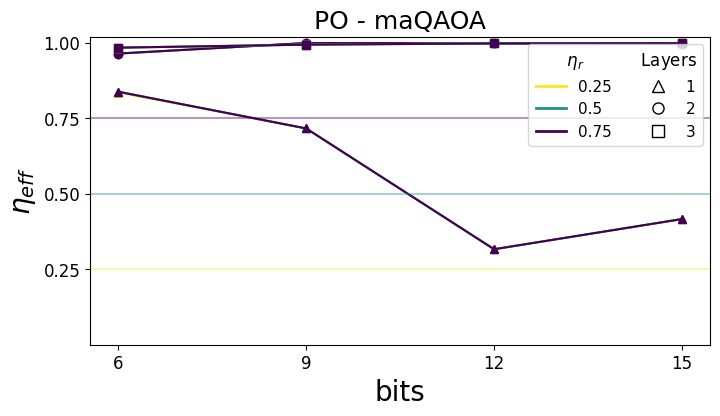

In [17]:
###### PORTFOLIO OPTIMIZATION

# file = open("./data_qaoa/test0_PO.txt", "rb")
# eta_eff_array_0 = pickle.load(file)
# file.close()

file = open("./data_qaoa/test1_PO_maqaoa.txt", "rb")
res = pickle.load(file)
file.close()

eta_eff_array = res["eta"]
layers_list = res["layers"]
n_bits_list = res["bits"]
problem_type = "PO"

markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        ax.plot(n_bits_list, y, "-", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")


# for j, layers in enumerate(layers_list):
#     for k, eta_req in enumerate(eta_req_list):
#         y = eta_eff_array_0[:, j, k]
#         ax.plot(n_bits_list, y, "--", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type + " - maQAOA", fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

fig.savefig(f"./eta_eff_plots/maQAOA_{problem_type}.pdf", bbox_inches='tight', format="pdf")

#### $\eta_{eff}$ with ma-QAOA for PO, oneshot strategy

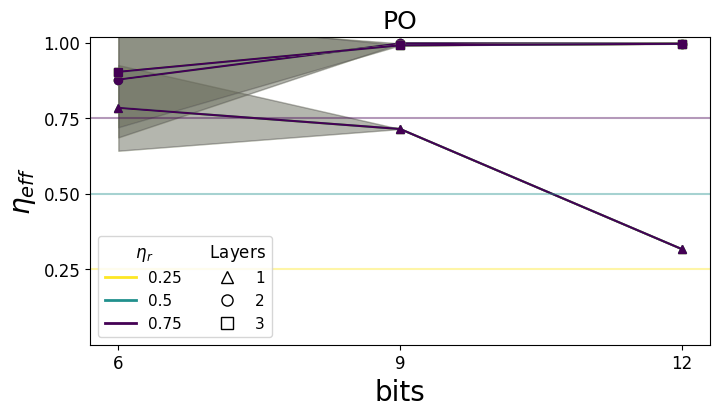

In [58]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics

problem_type = "PO"
M_strategy = "optimality" # "optimality"
vseed_list = np.arange(42, 1042, 100) # 42, 1042, 100 total
layers_list = np.array([1,2,3])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([6, 9, 12])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa_v2/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="best", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}_maqaoa.pdf", bbox_inches='tight', format="pdf")

## Noisy emulator

### store optimized circuits

### simulate trained circuit on noisy backend

In [ ]:
### run on H2-2

n_bits = 3
layers = 3
n_shots = 100
dir = "optimized_circuits_fromQIBO"


#### !!!! Uncomment only if you want to send the job to the server
# path = run_optimized_circuit_wnoise(n_bits, layers, n_shots = n_shots, dir_circ = dir, project_name = f"noisy_wQIBO_{n_shots}_shots")
results = check_job_execution(path)

In [ ]:
### Running all noisy executions (H2)

# n_bits_list = np.arange(3, 31, 3)
n_bits_list = np.array([3, 6, 9, 12, 15, 18, 21, 24, 27])
layers = 3
n_shots = 10000

for n_bits in n_bits_list:
    path = run_optimized_circuit_wnoise(n_bits, layers, n_shots = n_shots, dir = "optimized_circuits_fromQIBO", project_name = f"noisy_wQIBO_{n_shots}_shots")

In [ ]:
### check if a job has done

n_bits = 24
layers = 3
helios = True
proj_name = "noisy_wQIBO_10000_shots"

results = retrieve_noisy_job(n_bits, layers, proj_name=proj_name, helios = helios, allow_partial=True)
print_top_bitstrings(results, top=10)

### $\eta_{eff}$ for noisy backend